# 2026 年中国研究生数学建模竞赛 D 题·问题三
## 通信约束下的运输与中继联合调度方案

> **定位：** 在问题二的运输调度框架上叠加通信保障：判定每架运输无人机全程的通信状态（直连 / 中继 / 中断），设计中继无人机的悬停位置与服务时段，并把中继的能耗、架次与完成时间一并纳入优化。公共物理规则（航段几何、时间、能耗、充电）与问题一、二保持一致；本 Notebook 自带完整实现。数据读取与图件输出目录按当前工作区配置。

### 1 问题

| 项目 | 内容 |
|---|---|
| 新增对象 | 固定网关 G01（设于 O01，天线离地 20 m）；中继无人机 R01、R02（机型 R）与 6 组可更换能源组件 |
| 新增硬约束 | 运输无人机在爬升、巡航、下降、投送全过程连续通信；与 G01 直连可用，或“运输机—中继机—G01”两段链路同时可用；不允许中继间多跳；每架运输机同一时刻只由 G01 或一架中继机保障 |
| 中继决策 | 悬停位置（须在 DEM 范围内）、飞行海拔（离地 ≤ 300 m）、服务时段、能源组件分配与架次 |
| 链路判定 | 地形遮挡 bᵢⱼ（30 m DEM 视线判定）→ 自由空间损耗 + 遮挡附加损耗 → 与双向链路预算比较 |
| 任务 1 | 综合优化物资配送及时性、联合任务完成时间（运输机与中继机全部返回 O01 的最晚时刻）、运输与中继总能耗、两类无人机使用架次，并说明权衡 |
| 任务 2 | 给出联合调度方案：货箱交付、资源使用与通信保障情况 |
| 论文需呈现 | 链路预算与覆盖半径、通信阴影分析、中继站选址依据、联合航线图与联合甘特图、通信状态时间线、四指标权衡、可行性与通信连续性检查 |

### 2 与问题二的数据继承关系

- **完全继承：** 节点与 DEM、机型和货箱、航段矩阵、逐箱时限、运输时间与能耗、共享电池充电规则，以及问题二的列表调度解码器和 ALNS 框架。
- **空间层扩展：** 对每条航段的三维轨迹逐点判定直连可用性，识别通信盲区；在候选网格上做最大覆盖选址，确定中继悬停点。
- **时间层扩展：** 将每条运输架次在盲区内的时间段转换为对中继站的服务需求区间；中继架次由第二个列表调度器安排，其能耗、架次和返仓时刻进入联合目标。
- 问题二的推荐方案作为本问 ALNS 的热启动；通信约束会排除部分航段并改变架次顺序，联合方案与问题二方案的差异即“通信保障代价”。

### 3 技术路线

链路参数 → 双向链路预算 $L_{max}$ → 覆盖半径（视距 / 遮挡）

DEM + 航段三维采样 → 视线判定 → 直连覆盖与通信盲区

候选悬停网格（离地 ≤ 300 m） → 贪心最大覆盖 → 中继站选址

问题二 ALNS（限于通信可行航段） → 运输架次 → 中继服务需求区间

中继列表调度（占位、续航会话、能源组件充电） → 联合方案

联合目标（及时性 / 联合完成时间 / 总能耗 / 两类架次）→ 情景权重 → 通信连续性与资源可行性检验



## 4 通信规则的数学化（附录 3）

**(1) 双向链路预算。** 接收门限 $P_{th}^{b}=P_{sens}^{b}+M^{b}=-98+8=-90\,\mathrm{dBm}$。方向 $a\to b$ 的最大允许损耗 $L_{\max}^{a\to b}=P_t^a+G_t^a+G_r^b-L_{sys}-P_{th}^b$，双向取小：

| 链路 | $a\to b$ | $b\to a$ | $L_{\max}^{ab}$ |
|---|---:|---:|---:|
| 运输机 $\leftrightarrow$ G01 | $20 + 3 + 12 - 3 + 90 = 122$ | $27 + 12 + 3 - 3 + 90 = 129$ | **122 dB** |
| 运输机 $\leftrightarrow$ 中继接入端 | $20 + 3 + 6 - 3 + 90 = 116$ | $20 + 6 + 3 - 3 + 90 = 116$ | **116 dB** |
| 中继回传端 $\leftrightarrow$ G01 | $19 + 8 + 12 - 3 + 90 = 126$ | $27 + 12 + 8 - 3 + 90 = 134$ | **126 dB** |

**(2) 传播损耗与覆盖半径。** $L_{FSPL}=32.45+20\lg f_{MHz}+20\lg D_{km}=100.05+20\lg D_{km}$（$f=2400$ MHz），遮挡增加 $L_{obs}=10$ dB。令 $L_{path}\leq L_{\max}$ 得等效覆盖半径：直连视距 $12.5$ km / 遮挡 $3.96$ km；接入视距 $6.27$ km / 遮挡 $1.98$ km；回传视距 $19.8$ km / 遮挡 $6.27$ km。研究区半径不足 $9$ km，因此直连是否可用几乎完全取决于地形遮挡：视距畅通可直连，被山体遮挡且距 G01 超过 $3.96$ km 即中断。

**(3) 地形遮挡判定。** 端点 $i,j$ 的三维连线以 $15$ m 步长采样，每个采样点落入的 DEM 像元若地面高程高于连线高度则 $b_{ij}=1$（端点所在像元除外，端点本身高于地面）。这是标准的“剖面视线法”，与附录要求的“视线连接与沿途地形是否发生遮挡”一致。

**(4) 通信状态。** 直连可用 → 直连；否则接入链路与回传链路同时可用 → 中继；否则中断。本问要求运输机全程不出现中断。

**(5) 中继无人机时间与能耗。** 由 O01 出发：固定准备 $180$ s → 爬升至航段巡航海拔 $H^c$（沿线最高像元 + $50$ m）→ 巡航（$15$ m/s，功率 $1.15$ kW）→ 升/降至悬停海拔 $z_h$（离地 $\leq 300$ m）→ 建链 $30$ s → 服务 → 返回。爬升附加能耗按运输机同一关系，质量取起飞总质量 $23.5$ kg；悬停功率 $1.05$ kW，通信附加 $0.05$ kW（建链与服务期间）；能源组件可用 $3.2$ kWh，返航下限 $20\%$，即单次能耗 $\leq 2.56$ kWh，在站服务能力约 $2.3$ h（扣除往返飞行后约 $2.1$ h）；同一中继机相邻架次周转时间 $300$ s；$6$ 组能源组件按两阶段模型充电（$T^{full}=1800$ s）。

**(6) 联合目标。** 在问题二四指标基础上：$f_M$ 改为联合完成时间 $\max(\text{运输返仓},\text{中继返仓})$；$f_E$ 改为运输 + 中继总能耗；$f_N$ 改为运输架次 + 中继架次；通信中断时长作为罚项（每中断 $1$ h 罚 $100$，每次中断罚 $5$），推荐权重仍为 $(3,1.5,1,0.5)$。


## 5 运行环境、字体与图表主题

与问题一、二相同：英文与数字优先使用 Times New Roman，中文优先使用宋体；图件按 300 dpi 导出，Matplotlib 需为 3.6 或以上。当前机器若无宋体，字体函数会按可用中文字体回退，并在输出中提示。



In [1]:
import math, json, time, itertools, bisect, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import font_manager
from matplotlib.colors import LightSource, LinearSegmentedColormap, ListedColormap, Normalize, BoundaryNorm
from matplotlib.patches import Rectangle, Polygon as MplPolygon, FancyBboxPatch
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection, PolyCollection
import matplotlib.patheffects as pe

warnings.filterwarnings('ignore')
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40); pd.set_option('display.max_rows', 120)
T_START = time.time()

# ---------- 本机目录：无论从项目根目录还是 002-Code 启动内核均可运行 ----------
NOTEBOOK_DIR = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / '26-Modeling/002-Code/Q3.ipynb').exists()), None)
PROJECT = NOTEBOOK_DIR if NOTEBOOK_DIR is not None else Path.cwd().parents[1]
BASE_DIR = PROJECT / '26-Modeling/001-Issue/D题'
OUT_DIR = PROJECT / '26-Modeling/003-Picture/问题三'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def find_file(name):
    """先在当前目录找，找不到再递归子目录找。"""
    p = BASE_DIR / name
    if p.exists():
        return p
    hits = list(BASE_DIR.rglob(name))
    if hits:
        return hits[0]
    raise FileNotFoundError(f'未找到文件 {name}：请检查 001-Issue/D题 下的原始附件')


# ────────── 字体 ──────────
def setup_fonts():
    cands = ['C:/Windows/Fonts/simsun.ttc', 'C:/Windows/Fonts/times.ttf', 'C:/Windows/Fonts/timesbd.ttf',
             '/System/Library/Fonts/Supplemental/Songti.ttc', '/System/Library/Fonts/Supplemental/Times New Roman.ttf',
             '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf']
    for c in cands:
        if Path(c).exists():
            try:
                font_manager.fontManager.addfont(c)
            except Exception:
                pass
    names = {f.name for f in font_manager.fontManager.ttflist}
    cn = next((n for n in ['SimSun', '宋体', 'Songti SC', 'Noto Serif CJK SC', 'Noto Serif CJK JP', 'Source Han Serif SC',
                           'Noto Sans CJK SC', 'Noto Sans CJK JP', 'Microsoft YaHei', 'SimHei', 'WenQuanYi Micro Hei'] if n in names), None)
    en = next((n for n in ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'STIXGeneral'] if n in names), 'serif')
    fam = [en] + ([cn] if cn else [])
    plt.rcParams['font.family'] = fam
    plt.rcParams['font.serif'] = fam
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['mathtext.fontset'] = 'stix'
    return en, cn


EN_FONT, CN_FONT = setup_fonts()
print(f'英文/数字字体: {EN_FONT}    中文字体: {CN_FONT}' +
      ('' if CN_FONT == 'SimSun' else '（提示：未检测到宋体，已使用替代中文字体）'))


# ────────── 统一视觉主题 ──────────
PAL = dict(indigo='#1F3A5F', teal='#2A9D8F', coral='#E76F51', gold='#E9C46A', plum='#6D597A',
           sky='#8AB6D6', grey='#8D99AE', ink='#2B2D42', mist='#E4E6EB', sand='#B8AFA2')
TYPE_COLOR = {'A': '#2A9D8F', 'B': '#1F3A5F', 'C': '#E76F51'}  # 机型
MAT_COLOR = {'医疗物资': '#C8553D', '饮用水': '#3A7CA5', '应急食品': '#E9B44C', '生活卫生用品': '#7B6D8D'}  # 物资
MAT_ABBR = {'医疗物资': 'MED', '饮用水': 'WAT', '应急食品': 'FOD', '生活卫生用品': 'HYG'}
CMAP_SEQ = LinearSegmentedColormap.from_list('seq', ['#2A9D8F', '#1F3A5F', '#E76F51'])  # 青绿→靛蓝→珊瑚

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.edgecolor': '#A4A6E9', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E4E6EB', 'grid.linewidth': 0.6,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8.5, 'legend.frameon': False,
    'xtick.color': '#A4A6E9', 'ytick.color': '#A4A6E9', 'axes.labelcolor': '#2B2D42', 'text.color': '#2B2D42',
    'lines.linewidth': 1.6, 'patch.linewidth': 0.8,
})

HALO = [pe.withStroke(linewidth=2.5, foreground='white')]  # 文字白色描边，避免压在地形上看不清


def savefig(fig, name):
    fig.savefig(OUT_DIR / f'{name}.png')
    print(f'🖼️ 已保存 {OUT_DIR.name}/{name}.png')

英文/数字字体: Times New Roman    中文字体: Songti SC（提示：未检测到宋体，已使用替代中文字体）


## 6 数据读取与数据台账

在问题二的基础上增加 中继无人机数据.xlsx 与 通信链路参数.xlsx。读入后立即算出三条链路的双向预算与覆盖半径表，作为后续判定的常数。

In [2]:
def read_block(df, title):
    col0 = df[0].astype(str).str.strip()
    idx = int(col0.index[col0 == title][0])
    header = [str(h).strip() for h in df.iloc[idx + 1].tolist()]
    rows = []
    for k in range(idx + 2, len(df)):
        r = df.iloc[k]
        if r.isna().all():
            break
        rows.append(r.tolist())
    out = pd.DataFrame(rows, columns=header).dropna(axis=1, how='all')
    return out.loc[:, [c for c in out.columns if c != 'nan']].reset_index(drop=True)

raw_node = pd.read_excel(find_file('调度中心与服务区.xlsx'), header=None)
depot = read_block(raw_node, '调度中心').rename(columns={
    '调度中心编号':'id', '调度中心名称':'name', '经度（°）':'lon', '纬度（°）':'lat', '海拔（m）':'elev'})
areas = read_block(raw_node, '服务区').rename(columns={
    '服务区编号':'id', '服务区名称':'name', '经度（°）':'lon', '纬度（°）':'lat',
    '海拔（m）':'elev', '本次需保障人口（人）':'pop'})
for c in ('lon','lat','elev'):
    depot[c] = pd.to_numeric(depot[c]); areas[c] = pd.to_numeric(areas[c])
areas['pop'] = pd.to_numeric(areas['pop']).astype(int)
AREA_IDS = areas['id'].tolist()
LON_O, LAT_O, Z_O = depot.loc[0, ['lon','lat','elev']].astype(float)

raw_uav = pd.read_excel(find_file('运输无人机数据.xlsx'), header=None)
uav_cols = {
    '机型编号':'g', '机型名称':'name', '含电池空载总质量（kg）':'m0',
    '最大载货质量（kg）':'Q', '可用装载体积（m³）':'V', '计划巡航速度（m/s）':'v_c',
    '空载标准航程（m）':'L0', '满载标准航程（m）':'LF', '电池可用能量（kWh）':'E_use',
    '返航电量下限（%）':'rho_pct', '工位固定准备时间（s）':'t_prep',
    '每箱装载时间（s）':'t_load', '接收点基础交接时间（s）':'t_hand',
    '每箱增加交接时间（s）':'t_box', '最大爬升速度（m/s）':'v_up',
    '最大下降速度（m/s）':'v_dn', '爬升能耗效率':'eta_up', '下降能耗效率':'eta_dn'}
uav = read_block(raw_uav, '三类机型参数').rename(columns=uav_cols)
for c in uav.columns.difference(['g','name']): uav[c] = pd.to_numeric(uav[c])
uav['rho'] = uav['rho_pct'] / 100
uav = uav.set_index('g')
TYPES = uav.index.tolist()
fleet = read_block(raw_uav, '逐架无人机清单')
battery = read_block(raw_uav, '共享电池库存')

xlsx_demand = find_file('物资需求与配送时限.xlsx')
boxes = pd.read_excel(xlsx_demand, sheet_name='逐箱货箱清单').rename(columns={
    '货箱编号':'box', '服务区编号':'area', '物资类型':'mat', '单箱质量（kg）':'mass',
    '单箱体积（m³）':'vol', '是否首批保障':'first', '首批截止时间（s）':'deadline',
    '期望送达时间（s）':'expected', '应急优先系数':'priority'})
boxes['first'] = boxes['first'].eq('是')
boxes['mass'] = pd.to_numeric(boxes['mass']); boxes['vol'] = pd.to_numeric(boxes['vol'])
MAT_ORDER = ['医疗物资','饮用水','应急食品','生活卫生用品']

def load_dem():
    try:
        m = sio.loadmat(find_file('镇龙乡及周边30米DEM.mat'))
        dem = m['dem'].astype(np.float32)
        tr = m['transform'].ravel()
        nodata = float(m['nodata'].ravel()[0])
        dx, lon0, dy, lat0 = float(tr[0]), float(tr[2]), float(-tr[4]), float(tr[5])
        src = 'MAT'
    except Exception:
        import tifffile
        with tifffile.TiffFile(find_file('镇龙乡及周边30米DEM.tif')) as tf:
            dem = tf.asarray().astype(np.float32)
            tags = tf.pages[0].tags
            scale = tags['ModelPixelScaleTag'].value
            tie = tags['ModelTiepointTag'].value
            dx, dy = float(scale[0]), float(scale[1])
            lon0, lat0 = float(tie[3]), float(tie[4])
            nodata = float(tags['GDAL_NODATA'].value)
        src = 'GeoTIFF'
    dem[dem == nodata] = np.nan
    return dem, dict(dx=dx, dy=dy, lon0=lon0, lat0=lat0, src=src)

DEM, GEO = load_dem()
NROW, NCOL = DEM.shape
def read_csv_cn(name):
    return pd.read_csv(find_file(name), encoding='utf-8-sig')

roads=read_csv_cn('镇龙乡及周边道路.csv')
water=read_csv_cn('镇龙乡及周边水体.csv')
rivers=read_csv_cn('镇龙乡及周边水系.csv')
LON_C = GEO['lon0'] + (np.arange(NCOL) + .5) * GEO['dx']
LAT_C = GEO['lat0'] - (np.arange(NROW) + .5) * GEO['dy']
def to_pix(lon, lat):
    return (lon-GEO['lon0'])/GEO['dx'], (GEO['lat0']-lat)/GEO['dy']

boxes['t_hard']=np.where(boxes['first'],boxes['deadline'],np.where(boxes['mat'].eq('医疗物资'),boxes['expected'],np.inf))
boxes['hard_kind']=np.where(boxes['first'],'首批',np.where(boxes['mat'].eq('医疗物资'),'医疗','-'))

# 实体资源来自附件，而不是按机型假设无限架无人机或电池。
UAV_TYPE=dict(zip(fleet['无人机编号'], fleet['机型编号']))
UAV_LIST=tuple(fleet['无人机编号'])
BATT={r['机型编号']:(int(r['共享电池组总数（组）']), float(r['等效完全充电时间（s）'])) for _,r in battery.iterrows()}
BATTS={g:tuple(f'{g}-B{k+1}' for k in range(BATT[g][0])) for g in TYPES}
NODE_IDS=('O01',*AREA_IDS); AREA_IDX={a:i+1 for i,a in enumerate(AREA_IDS)}
NODES=pd.concat([depot[['id','lon','lat','elev']], areas[['id','lon','lat','elev']]],ignore_index=True)
LONS=NODES.lon.to_numpy(float); LATS=NODES.lat.to_numpy(float); ELEV=NODES.elev.to_numpy(float)
box_data=boxes.reset_index(drop=True).copy(); BOX_IDS=tuple(box_data.box); BOX_IDX={b:i for i,b in enumerate(BOX_IDS)}
b_area=np.array([AREA_IDX[a] for a in box_data.area],int)
b_mass=box_data.mass.to_numpy(float); b_vol=box_data.vol.to_numpy(float)
b_mat=box_data.mat.to_numpy(str); b_exp=box_data.expected.to_numpy(float)
b_w=box_data.priority.to_numpy(float)
# 首批箱按首批截止时间；非首批医疗箱按期望送达时间。
b_hard=box_data['t_hard'].to_numpy(float)
b_kind=box_data['hard_kind'].to_numpy(str)
UAVS=list(UAV_TYPE.items())
UAV_COLOR={u:TYPE_COLOR[g] for u,g in UAVS}

# 中继与通信参数按附件块标题读取。
raw_relay=pd.read_excel(find_file('中继无人机数据.xlsx'),header=None)
relay_raw=read_block(raw_relay,'中继机型参数').iloc[0]
relay_fleet=read_block(raw_relay,'逐架中继无人机清单')
relay_stock=read_block(raw_relay,'共享能源组件库存')
R=dict(m0=float(relay_raw['计划起飞总质量（kg）']),v_c=float(relay_raw['计划巡航速度（m/s）']),
       P_cruise=float(relay_raw['巡航功率（kW）']),E_use=float(relay_raw['能源组件可用能量（kWh）']),
       rho=float(relay_raw['返航电量下限（%）'])/100,t_prep=float(relay_raw['工位固定准备时间（s）']),
       t_link=float(relay_raw['建链时间（s）']),t_turn=float(relay_raw['架次周转时间（s）']),
       v_up=float(relay_raw['最大爬升速度（m/s）']),v_dn=float(relay_raw['最大下降速度（m/s）']),
       eta_up=float(relay_raw['爬升能耗效率']),P_hover=float(relay_raw['悬停功率（kW）']),
       P_comm=float(relay_raw['通信附加功率（kW）']),h_max=float(relay_raw['最大悬停离地高度（m）']))
R['g']=str(relay_raw.get('机型编号','R'))
R['budget']=(1-R['rho'])*R['E_use']
RELAYS=tuple(relay_fleet['中继无人机编号'])
N_COMP=int(relay_stock.iloc[0]['共享能源组件总数（组）']);T_FULL_R=float(relay_stock.iloc[0]['等效完全充电时间（s）'])
COMPS=tuple(f'R-C{k+1}' for k in range(N_COMP))
raw_link=pd.read_excel(find_file('通信链路参数.xlsx'),header=None)
link=read_block(raw_link,'通信系统与端点参数')
LK={(r['参数类别'],r['参数名称']):float(r['参数值']) for _,r in link.iterrows()}
F_MHZ=LK['传播参数','载波频率（MHz）'];L_SYS=LK['传播参数','系统损耗（dB）']
L_OBS=LK['传播参数','地形遮挡附加损耗（dB）'];P_SENS=LK['接收参数','接收灵敏度（dBm）'];MARGIN=LK['接收参数','衰落裕量（dB）']
P_TH=P_SENS+MARGIN
H_GW=LK['固定网关 G01','天线离地高度（m）']
DEV={'T':(LK['运输无人机','发射功率（dBm）'],LK['运输无人机','天线增益（dBi）']),
     'A':(LK['中继接入端','发射功率（dBm）'],LK['中继接入端','天线增益（dBi）']),
     'B':(LK['中继回传端','发射功率（dBm）'],LK['中继回传端','天线增益（dBi）']),
     'G':(LK['固定网关 G01','发射功率（dBm）'],LK['固定网关 G01','天线增益（dBi）'])}
def link_budget(x,y):
    p1,g1=DEV[x];p2,g2=DEV[y];threshold=P_TH
    return min(p1+g1+g2-L_SYS-threshold,p2+g2+g1-L_SYS-threshold)
LMAX={'T-G':link_budget('T','G'),'T-R':link_budget('T','A'),'R-G':link_budget('B','G')}
FSPL0=32.45+20*math.log10(F_MHZ)
RAD={k:(10**((L-FSPL0)/20),10**((L-FSPL0-L_OBS)/20)) for k,L in LMAX.items()}

link_df=pd.DataFrame([
    dict(链路=k, 双向预算dB=v, 视距覆盖半径km=RAD[k][0], 遮挡覆盖半径km=RAD[k][1])
    for k,v in LMAX.items()
]).set_index('链路')
print(f"DEM: {GEO['src']}, {NROW}×{NCOL}; 节点 1+{len(areas)}; 货箱 {len(boxes)} 箱 {boxes.mass.sum():.0f} kg")
print(f"中继无人机: {list(RELAYS)} (机型 {R['g']}, 起飞总质量 {R['m0']:.1f} kg, 可用能量 {R['E_use']:.1f} kWh, 单次预算 {R['budget']:.2f} kWh, 悬停+通信 {R['P_hover']+R['P_comm']:.2f} kW, 最大离地 {R['h_max']:.0f} m); 能源组件 {N_COMP} 组, T_full={T_FULL_R:.0f} s")
print(f"载波 {F_MHZ:.0f} MHz, 系统损耗 {L_SYS:.1f} dB, 遮挡附加 {L_OBS:.1f} dB, 接收门限 {P_TH:.1f} dBm, G01 天线离地 {H_GW:.1f} m")
display(link_df.round(2))
print('实体无人机：' + '、'.join(f'{u}({g})' for u,g in UAVS))
print('共享电池：' + '；'.join(
    f"机型{g} {BATT[g][0]}组（含机上{sum(1 for _,gg in UAVS if gg==g)}组，备用{BATT[g][0]-sum(1 for _,gg in UAVS if gg==g)}组），T_full={BATT[g][1]:.0f} s"
    for g in TYPES))


DEM: MAT, 1309×1486; 节点 1+15; 货箱 80 箱 758 kg
中继无人机: ['R01', 'R02'] (机型 R, 起飞总质量 23.5 kg, 可用能量 3.2 kWh, 单次预算 2.56 kWh, 悬停+通信 1.10 kW, 最大离地 300 m); 能源组件 6 组, T_full=1800 s
载波 2400 MHz, 系统损耗 3.0 dB, 遮挡附加 10.0 dB, 接收门限 -90.0 dBm, G01 天线离地 20.0 m


,双向预算dB,视距覆盖半径km,遮挡覆盖半径km
链路,,,
T-G,122.0,12.51,3.96
T-R,116.0,6.27,1.98
R-G,126.0,19.83,6.27


实体无人机：U01(A)、U02(A)、U03(A)、U04(A)、U05(B)、U06(B)、U07(C)、U08(C)
共享电池：机型A 6组（含机上4组，备用2组），T_full=1800 s；机型B 4组（含机上2组，备用2组），T_full=2400 s；机型C 4组（含机上2组，备用2组），T_full=3000 s


## 7 航段矩阵、局部平面坐标与视线判定

航段矩阵（距离、巡航海拔、逐机型时间-能耗系数）与问题二完全相同。通信判定需要三维几何，因此再建立一个以 O01 为原点的局部东北平面坐标系（m），视线采样在该坐标系中进行：

- `los_ok(P, Q)`：对一批端点 $P$ 与公共端点 $Q$，沿连线每 15 m 取样，查 DEM 像元高程，任一内部采样点地面高于连线即遮挡（向量化，一次可判定上万条视线）。
- `link_ok(P, Q, Lmax)`：$L_{path}=L_{FSPL}(D_{3D})+L_{obs}b$，与 $L_{max}$ 比较。

图 1 画出三条链路的损耗曲线与预算线，直观给出六个覆盖半径。


局部平面：O01 为原点；服务区坐标范围 x=[-6355, 5407] m, y=[-365, 7863] m
🖼️ 已保存 问题三/图01_链路预算与覆盖半径.png


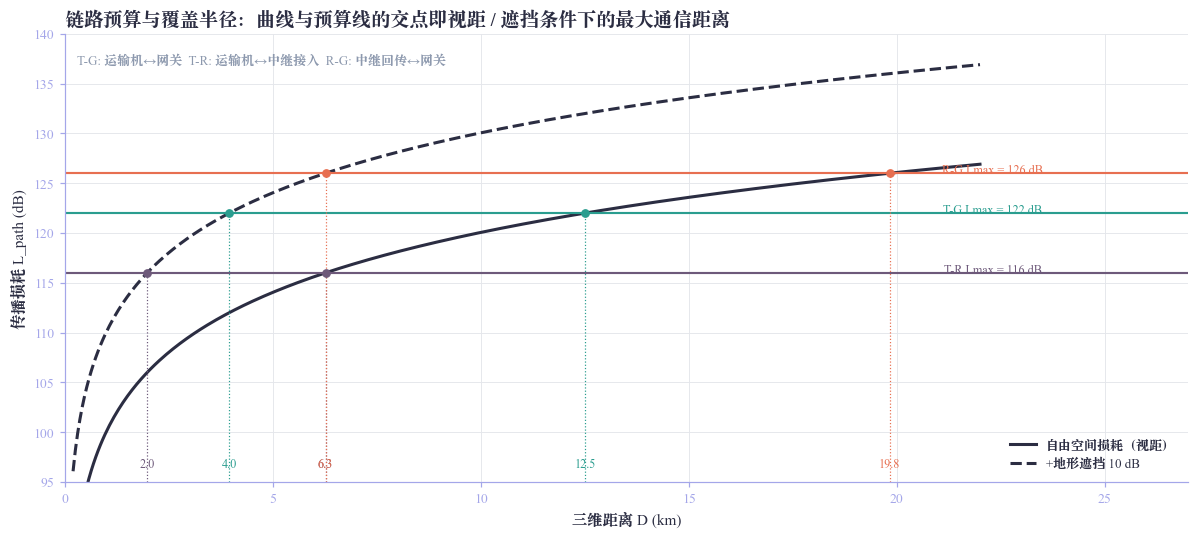

In [3]:
A_WGS, F_WGS = 6378137.0, 1 / 298.257223563
E2_WGS = 2 * F_WGS - F_WGS ** 2

def dist_m(lon0, lat0, lon1, lat1):
    phi = math.radians((lat0 + lat1) / 2); s2 = math.sin(phi) ** 2
    M = A_WGS * (1 - E2_WGS) / (1 - E2_WGS * s2) ** 1.5; N = A_WGS / math.sqrt(1 - E2_WGS * s2)
    return math.hypot(math.radians(lat1 - lat0) * M, math.radians(lon1 - lon0) * N * math.cos(phi))

def traverse_cells(x0, y0, x1, y1):
    ix, iy = math.floor(x0), math.floor(y0); dx, dy = x1 - x0, y1 - y0
    sx = 1 if dx > 0 else -1; sy = 1 if dy > 0 else -1
    tdx = abs(1 / dx) if dx else math.inf; tdy = abs(1 / dy) if dy else math.inf
    tmx = ((ix + 1 - x0) / dx if dx > 0 else (ix - x0) / dx) if dx else math.inf
    tmy = ((iy + 1 - y0) / dy if dy > 0 else (iy - y0) / dy) if dy else math.inf
    cells = [(iy, ix)]
    while len(cells) < 10000:
        if tmx < tmy:
            if tmx > 1: break
            ix += sx; tmx += tdx
        else:
            if tmy > 1: break
            iy += sy; tmy += tdy
        cells.append((iy, ix))
    return cells

CLEARANCE, H_SERVICE, G0 = 50.0, 30.0, 9.81
NODE_IDS = ['O01'] + AREA_IDS; NN = len(NODE_IDS)
LONS = [float(depot.lon[0])] + areas.lon.tolist()
LATS = [float(depot.lat[0])] + areas.lat.tolist()
ALT_OP = [float(depot.elev[0])] + [z + H_SERVICE for z in areas.elev.tolist()]
D = np.zeros((NN, NN)); HC = np.zeros((NN, NN)); PIXELS = np.zeros((NN, NN), int)
for i in range(NN):
    for j in range(i + 1, NN):
        D[i, j] = D[j, i] = dist_m(LONS[i], LATS[i], LONS[j], LATS[j])
        x0, y0 = to_pix(LONS[i], LATS[i]); x1, y1 = to_pix(LONS[j], LATS[j])
        cells = traverse_cells(x0, y0, x1, y1)
        HC[i, j] = HC[j, i] = max(DEM[r, c] for r, c in cells) + CLEARANCE
        PIXELS[i, j] = PIXELS[j, i] = len(cells)

LEG_T, LEG_A, LEG_B, HUP, HDN = {}, {}, {}, {}, {}
for g in TYPES:
    p = uav.loc[g]; T = np.zeros((NN, NN)); A = np.zeros((NN, NN)); B = np.zeros((NN, NN))
    HU = np.zeros((NN, NN)); HD = np.zeros((NN, NN))
    for i in range(NN):
        for j in range(NN):
            if i == j: continue
            hup = max(0., HC[i, j] - ALT_OP[i]); hdn = max(0., HC[i, j] - ALT_OP[j])
            T[i, j] = hup / p['v_up'] + D[i, j] / p['v_c'] + hdn / p['v_dn']
            A[i, j] = D[i, j] * p['E_use']; B[i, j] = G0 * hup / (p['eta_up'] * 3.6e6)
            HU[i, j] = hup; HD[i, j] = hdn
    LEG_T[g] = T.tolist(); LEG_A[g] = A.tolist(); LEG_B[g] = B.tolist(); HUP[g] = HU; HDN[g] = HD

def L_eq(p, q):
    return p['L0'] - (p['L0'] - p['LF']) * (q / p['Q']) ** 1.5

# ---------- 局部平面坐标（m） ----------
LAT0, LON0 = LATS[0], LONS[0]
_phi = math.radians(LAT0); _s2 = math.sin(_phi) ** 2
M_R = A_WGS * (1 - E2_WGS) / (1 - E2_WGS * _s2) ** 1.5; N_R = A_WGS / math.sqrt(1 - E2_WGS * _s2)

def to_xy(lon, lat):
    return np.radians(np.asarray(lon, float) - LON0) * N_R * math.cos(_phi), np.radians(np.asarray(lat, float) - LAT0) * M_R

def to_lonlat(x, y):
    return LON0 + np.degrees(np.asarray(x, float) / (N_R * math.cos(_phi))), LAT0 + np.degrees(np.asarray(y, float) / M_R)

NX, NY = to_xy(np.array(LONS), np.array(LATS))
H_GW = float(LK['固定网关 G01', '天线离地高度（m）'])
G01 = np.array([NX[0], NY[0], ALT_OP[0] + H_GW])  # 网关端点：O01 地面 + 天线离地高度

def dem_at_xy(x, y):
    lon, lat = to_lonlat(x, y); cx, cy = to_pix(lon, lat)
    ci = np.clip(np.floor(cx).astype(int), 0, NCOL - 1); ri = np.clip(np.floor(cy).astype(int), 0, NROW - 1)
    return DEM[ri, ci]

def los_ok(P, Q, step=15.):
    """P:(M,3)端点，Q:(3,)公共端点 → (M,)视线是否无遮挡（剖面视线法，15 m 采样）"""
    P = np.atleast_2d(P).astype(float); Q = np.asarray(Q, float)
    if len(P) == 0: return np.zeros(0, dtype=bool)
    d = np.linalg.norm(P[:, :2] - Q[:2], axis=1)
    n = int(np.ceil(d.max() / step)) + 2; t = np.linspace(0, 1, n)[None, :]
    x = P[:, 0, None] + (Q[0] - P[:, 0, None]) * t
    y = P[:, 1, None] + (Q[1] - P[:, 1, None]) * t
    z = P[:, 2, None] + (Q[2] - P[:, 2, None]) * t
    terrain = dem_at_xy(x.ravel(), y.ravel()).reshape(x.shape)
    return ~np.any(terrain[:, 1:-1] > z[:, 1:-1], axis=1)

def path_loss(P, Q):
    P = np.atleast_2d(P).astype(float); Q = np.asarray(Q, float)
    Dkm = np.linalg.norm(P - Q, axis=1) / 1000
    return FSPL0 + 20 * np.log10(np.maximum(Dkm, 1e-6)) + L_OBS * (~los_ok(P, Q)).astype(float)

def link_ok(P, Q, Lmax):
    return path_loss(P, Q) <= Lmax

print(f'局部平面：O01 为原点；服务区坐标范围 x=[{NX[1:].min():.0f}, {NX[1:].max():.0f}] m, y=[{NY[1:].min():.0f}, {NY[1:].max():.0f}] m')

# 后续章节沿用逐航段轨迹结构，链路判定统一调用上面的 los_ok / link_ok。
DIST, HCRUISE = D, HC
GEOM = {(i, j): (D[i, j], HC[i, j], max(0., HC[i, j] - ALT_OP[i]),
                 max(0., HC[i, j] - ALT_OP[j]), PIXELS[i, j])
        for i in range(NN) for j in range(NN) if i != j}

def leg_samples(i, j, step=30.):
    d, H, up, dn, _ = GEOM[i, j]
    p0 = np.array([NX[i], NY[i], ALT_OP[i]]); p1 = np.array([NX[j], NY[j], ALT_OP[j]])
    a = np.array([NX[i], NY[i], H]); b = np.array([NX[j], NY[j], H])
    chunks = []; phase = []; seglen = []
    for p, q, tag in [(p0, a, 'up'), (a, b, 'cruise'), (b, p1, 'down')]:
        length = float(np.linalg.norm(q - p)); n = max(1, int(math.ceil(length / step)))
        frac = np.arange(1, n + 1) / n
        chunks.append(p[None, :] + frac[:, None] * (q - p)[None, :])
        phase.extend([tag] * n); seglen.extend([length / n] * n)
    return np.vstack(chunks), np.array(phase), np.array(seglen)

LEG = {}
for i in range(NN):
    for j in range(NN):
        if i == j: continue
        pp, ph, sl = leg_samples(i, j)
        LEG[i, j] = dict(P=pp, phase=ph, seglen=sl, direct=link_ok(pp, G01, LMAX['T-G']))
HAND_P = {a: np.array([NX[a], NY[a], ALT_OP[a]]) for a in range(1, NN)}
HAND_DIRECT = {a: bool(link_ok(HAND_P[a], G01, LMAX['T-G'])[0]) for a in HAND_P}

# ---------- 链路预算与覆盖半径：曲线与预算线的交点 ----------
fig, ax = plt.subplots(figsize=(11, 5))
dk = np.linspace(0.2, 22, 400); base = FSPL0 + 20 * np.log10(dk)
ax.plot(dk, base, color=PAL['ink'], lw=2.0, label='自由空间损耗（视距）')
ax.plot(dk, base + L_OBS, color=PAL['ink'], lw=2.0, ls='--', label=f'+地形遮挡 {L_OBS:.0f} dB')
for (k, L), col in zip(LMAX.items(), [PAL['teal'], PAL['plum'], PAL['coral']]):
    ax.axhline(L, color=col, lw=1.4)
    r0, r1 = RAD[k]
    ax.scatter([r0, r1], [L, L], color=col, s=24, zorder=4)
    ax.vlines([r0, r1], 95, L, color=col, lw=0.8, ls=':')
    ax.text(22.3, L, f'{k} Lmax = {L:.0f} dB', ha='center', fontsize=8, color=col)
    ax.text(r0, 96.5, f'{r0:.1f}', ha='center', fontsize=8, color=col)
    ax.text(r1, 96.5, f'{r1:.1f}', ha='center', fontsize=8, color=col)
ax.set_xlim(0, 27); ax.set_ylim(95, 140)
ax.set_xlabel('三维距离 D (km)'); ax.set_ylabel('传播损耗 L_path (dB)')
ax.set_title('链路预算与覆盖半径：曲线与预算线的交点即视距 / 遮挡条件下的最大通信距离', loc='left', fontsize=12.5)
ax.legend(loc='lower right')
ax.text(0.3, 137, 'T-G: 运输机↔网关  T-R: 运输机↔中继接入  R-G: 中继回传↔网关',
        fontsize=8.5, color=PAL['grey'])
fig.tight_layout(); savefig(fig, '图01_链路预算与覆盖半径'); plt.show()


## 8 直连通信盲区分析（空间层 I）

对全部 240 条有向航段按题目规则生成三维轨迹：起点垂直爬升（10 m 一采样）→ 巡航海拔水平飞行（30 m 一采样）→ 终点垂直下降，再加上 15 个投送点（服务区地面 + 30 m）。对每个采样点判定与 G01 的直连可用性，得到逐航段直连中断比例与投送点直连状态；同时在 150 m 网格上计算离地 30 m 与离地 300 m 的直连覆盖，得到通信阴影图（图 2）。

结论先行：12/15 个投送点无直连；远距离服务区往返航段有 30%–45% 的轨迹处于阴影中——中继不是可选项而是必需品。

In [4]:
def leg_samples(i, j, ds=30.0, dz=10.0):
    """航段 i→j 的三维轨迹采样，返回局部坐标、phase 列表、每段长度。"""
    Hc = HC[i, j]
    pts, seglen = [], []
    phase = []
    zs = list(np.arange(ALT_OP[i], Hc, dz)) + [Hc]
    for k, z in enumerate(zs):
        pts.append((NX[i], NY[i], z, 'up'))
        seglen.append(0.0 if k == 0 else z - zs[k-1])
        phase.append('up')
    n = max(2, int(D[i, j] / ds) + 1)
    xs = np.linspace(0, 1, n)
    for k, t in enumerate(xs):
        pts.append((NX[i] + t * (NX[j] - NX[i]), NY[i] + t * (NY[j] - NY[i]), Hc, 'cruise'))
        seglen.append(0.0 if k == 0 else D[i, j] / (n - 1))
        phase.append('cruise')
    zs = list(np.arange(Hc, ALT_OP[j], -dz)) + [ALT_OP[j]]
    for k, z in enumerate(zs):
        pts.append((NX[j], NY[j], z, 'down'))
        seglen.append(0.0 if k == 0 else zs[k-1] - z)
        phase.append('down')
    P = np.array([p[:3] for p in pts])
    return P, np.array(phase), np.array(seglen)

t0 = time.time()
LEG = {}
for i in range(NN):
    for j in range(NN):
        if i == j:
            continue
        PP, ph, sl = leg_samples(i, j)
        LEG[i, j] = dict(P=PP, phase=ph, seglen=sl,
                         direct=link_ok(PP, G01, LMAX['T-G']))

HAND_P = {a:np.array([NX[a], NY[a], ALT_OP[a]]) for a in range(1, NN)}
HAND_DIRECT = {a:bool(link_ok(HAND_P[a][None, :], G01, LMAX['T-G'])[0])
               for a in range(1, NN)}
n_tot = sum(len(v['direct']) for v in LEG.values())
n_out = sum(int((~v['direct']).sum()) for v in LEG.values())
print(f'航段轨迹采样 {n_tot} 点，其中直连不可用 {n_out} 点（{n_out/n_tot:.1%}），用时 {time.time()-t0:.1f} s')
available = '、'.join(NODE_IDS[a] for a, ok in HAND_DIRECT.items() if ok)
unavailable = '、'.join(NODE_IDS[a] for a, ok in HAND_DIRECT.items() if not ok)
print(f'投送点直连：可用 {available}；不可用 {unavailable}')

leg_rows = []
leg_index = []
for (i, j), v in LEG.items():
    outage = ~v['direct']
    leg_rows.append(dict(
        航段=f'{NODE_IDS[i]}→{NODE_IDS[j]}',
        采样点=len(v['direct']),
        直连中断点=int(outage.sum()),
        中断比例=float(outage.mean()),
        爬升段中断=int(np.sum(outage & (v['phase'] == 'up'))),
        巡航段中断=int(np.sum(outage & (v['phase'] == 'cruise'))),
        下降段中断=int(np.sum(outage & (v['phase'] == 'down')))))
    leg_index.append(i * NN + j - 1)
leg_out = pd.DataFrame(leg_rows, index=leg_index)
print('\nO01 出发的 15 条航段直连中断情况：')
display(leg_out[leg_out['航段'].str.startswith('O01→')]
        .sort_values('中断比例', ascending=False).round(3))

# ---------- 通信阴影网格（离地 30 m / 300 m） ----------
gx = np.arange(NX.min()-2500, NX.max()+2500, 150.0)
gy = np.arange(NY.min()-2200, NY.max()+2200, 150.0)
GXX, GYY = np.meshgrid(gx, gy)
gz = dem_at_xy(GXX.ravel(), GYY.ravel())
valid = np.isfinite(gz)
SHADOW = {}
for agl in [30.0, 300.0]:
    P = np.column_stack([GXX.ravel()[valid], GYY.ravel()[valid], gz[valid] + agl])
    covered = np.zeros(valid.size, dtype=bool)
    covered[valid] = link_ok(P, G01, LMAX['T-G'])
    SHADOW[agl] = covered.reshape(GXX.shape)
print(f'网格 {GXX.shape}；离地 30 m 直连覆盖 {SHADOW[30.0].mean():.1%}；离地 300 m 直连覆盖 {SHADOW[300.0].mean():.1%}')


航段轨迹采样 56648 点，其中直连不可用 27950 点（49.3%），用时 0.4 s
投送点直连：可用 S001、S006、S011；不可用 S002、S003、S004、S005、S007、S008、S009、S010、S012、S013、S014、S015

O01 出发的 15 条航段直连中断情况：


,航段,采样点,直连中断点,中断比例,爬升段中断,巡航段中断,下降段中断
1,O01→S002,278,126,0.453,0,116,10
11,O01→S012,292,130,0.445,0,115,15
7,O01→S008,308,135,0.438,0,123,12
2,O01→S003,312,135,0.433,0,111,24
14,O01→S015,258,81,0.314,0,70,11
8,O01→S009,217,67,0.309,0,59,8
13,O01→S014,255,76,0.298,0,50,26
3,O01→S004,305,88,0.289,0,70,18
4,O01→S005,213,60,0.282,0,45,15
9,O01→S010,202,38,0.188,0,28,10


网格 (85, 112)；离地 30 m 直连覆盖 20.5%；离地 300 m 直连覆盖 40.5%


🖼️ 已保存 问题三/图02_直连通信阴影图.png
直连通信阴影：投送点 12/15 无直连，航段轨迹 49% 处于阴影


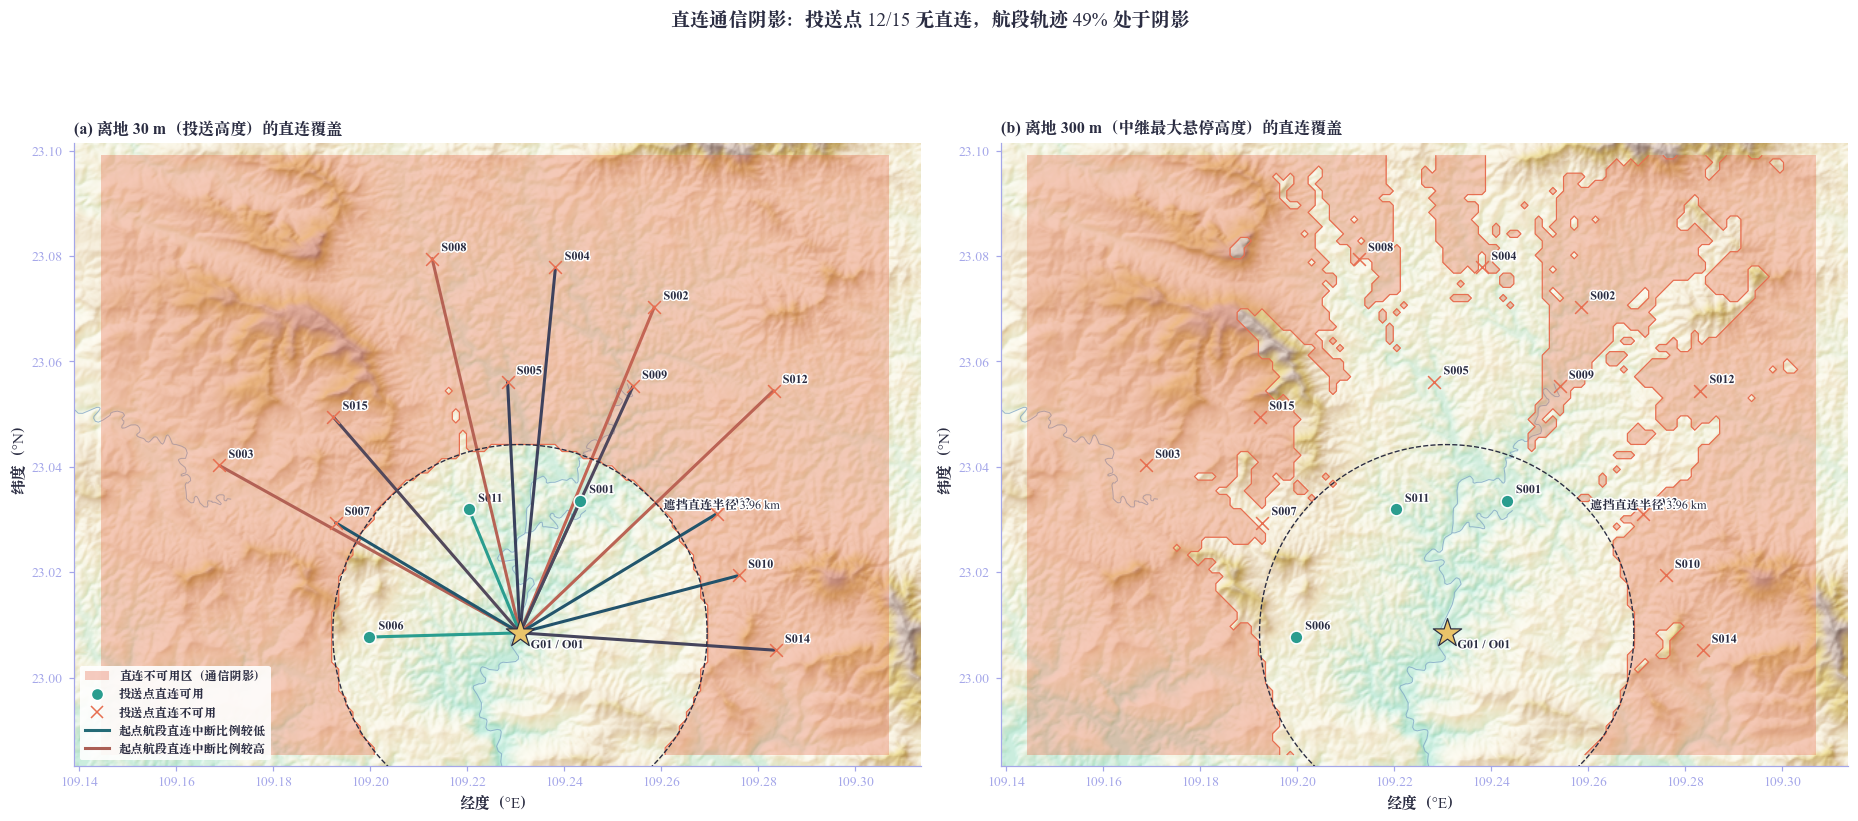

In [5]:
# ---------- 图 2：直连通信阴影图 ----------
pad_lon, pad_lat = 0.030, 0.022
lon_min, lon_max = min(LONS)-pad_lon, max(LONS)+pad_lon
lat_min, lat_max = min(LATS)-pad_lat, max(LATS)+pad_lat
c0, c1 = np.searchsorted(LON_C, [lon_min, lon_max])
r1, r0 = NROW - np.searchsorted(LAT_C[::-1], [lat_min, lat_max])
sub = DEM[r0:r1, c0:c1]
extent = [GEO['lon0']+c0*GEO['dx'], GEO['lon0']+c1*GEO['dx'],
          GEO['lat0']-r1*GEO['dy'], GEO['lat0']-r0*GEO['dy']]
ASPECT = 1 / math.cos(math.radians((lat_min+lat_max)/2))
m_per_deg_lon = dist_m(LONS[0], LATS[0], LONS[0]+0.01, LATS[0]) / 0.01
map_hypso = LinearSegmentedColormap.from_list(
    'hypso', ['#9CDCC6', '#E3E7C8', '#EFE3C3', '#DFC9A9', '#C7A95D', '#B39B8E', '#A18E86'])
rgb = LightSource(azdeg=315, altdeg=40).shade(
    np.nan_to_num(sub, nan=float(np.nanmean(sub))), cmap=map_hypso,
    blend_mode='soft', vert_exag=1.2,
    dx=GEO['dx']*m_per_deg_lon, dy=GEO['dy']*m_per_deg_lon)
GLON, GLAT = to_lonlat(GXX, GYY)

def base_map(ax, alpha=0.9):
    ax.imshow(rgb, extent=extent, aspect=ASPECT, interpolation='bilinear',
              zorder=0, alpha=alpha)
    ax.grid(False)
    ax.add_collection(LineCollection(
        [grp[['经度', '纬度']].values for _, grp in rivers.groupby('水系要素编号')],
        colors='#7FA3C4', linewidths=0.65, alpha=0.75, zorder=1))
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)

fig, axes = plt.subplots(1, 2, figsize=(17, 7.6))
titles = ['(a) 离地 30 m（投送高度）的直连覆盖',
          '(b) 离地 300 m（中继最大悬停高度）的直连覆盖']
for ax, agl, title in zip(axes, [30.0, 300.0], titles):
    base_map(ax)
    ax.contourf(GLON, GLAT, (~SHADOW[agl]).astype(float),
                levels=[0.5, 1.5], colors=[PAL['coral']], alpha=0.35, zorder=2)
    ax.contour(GLON, GLAT, (~SHADOW[agl]).astype(float),
               levels=[0.5], colors=[PAL['coral']], linewidths=0.8, zorder=3)
    if agl == 30.0:
        for (i, j), v in LEG.items():
            if i == 0:
                frac = (~v['direct']).mean()
                ax.plot([LONS[i], LONS[j]], [LATS[i], LATS[j]],
                        color=CMAP_SEQ(min(1, frac/0.5)), lw=2.0,
                        zorder=4, solid_capstyle='round')
    for a in range(1, NN):
        ok = HAND_DIRECT[a]
        ax.scatter(LONS[a], LATS[a], s=70,
                   facecolor=PAL['teal'] if ok else PAL['coral'],
                   edgecolor='white', linewidth=1.0, zorder=6,
                   marker='o' if ok else 'x')
        ax.annotate(NODE_IDS[a], (LONS[a], LATS[a]), xytext=(6, 5),
                    textcoords='offset points', fontsize=8, fontweight='bold',
                    path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    ax.scatter([LONS[0]], [LATS[0]], s=380, marker='*', color=PAL['gold'],
               edgecolor=PAL['ink'], zorder=8)
    ax.annotate('G01 / O01', (LONS[0], LATS[0]), xytext=(7, -10),
                textcoords='offset points', fontsize=8, fontweight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    for rk in [RAD['T-G'][1]]:
        th = np.linspace(0, 2*np.pi, 200)
        cx, cy = to_lonlat(NX[0]+rk*1000*np.cos(th), NY[0]+rk*1000*np.sin(th))
        ax.plot(cx, cy, color=PAL['ink'], lw=0.9, ls='--', zorder=5)
        ax.text(*to_lonlat(NX[0]+rk*1000*math.cos(math.radians(40)),
                           NY[0]+rk*1000*math.sin(math.radians(40))),
                f'遮挡直连半径 {rk:.2f} km', fontsize=8, ha='left', va='bottom',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    ax.set_title(title, loc='left', fontsize=10.5)
    ax.set_xlabel('经度（°E）')
    ax.set_ylabel('纬度（°N）')

handles = [
    Rectangle((0, 0), 1, 1, facecolor=PAL['coral'], alpha=0.35,
              label='直连不可用区（通信阴影）'),
    Line2D([], [], marker='o', color='none', markerfacecolor=PAL['teal'],
           markeredgecolor='white', markersize=8, label='投送点直连可用'),
    Line2D([], [], marker='x', color=PAL['coral'], linestyle='none',
           markersize=8, label='投送点直连不可用'),
    Line2D([], [], color=CMAP_SEQ(0.25), lw=2,
           label='起点航段直连中断比例较低'),
    Line2D([], [], color=CMAP_SEQ(0.85), lw=2,
           label='起点航段直连中断比例较高')]
axes[0].legend(handles=handles, loc='lower left', fontsize=8,
               frameon=True, framealpha=0.9, edgecolor='none')
caption = (f'直连通信阴影：投送点 {sum(not v for v in HAND_DIRECT.values())}/15 无直连，'
           f'航段轨迹 {n_out/n_tot:.0%} 处于阴影')
fig.suptitle(caption, fontsize=12.5, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.96])
savefig(fig, '图02_直连通信阴影图')
print(caption)
plt.show()


## 9 中继站选址：候选网格上的最大覆盖（空间层 II）

**候选集。** 在研究区外扩 1.5 km 的范围内取 400 m 网格，悬停离地高度取上限 300 m（越高视距越好，300 m 的爬升能耗仅 0.03 kWh），要求回传链路 R–G 可用。

**覆盖对象。** 全部航段轨迹中直连不可用的采样点（约 2.8 万个）按 150 m × 150 m × 40 m 体素合并为代表点，投送点单独列出并赋予高权重（投送点无法覆盖意味着该服务区不可达）。候选 $c$ 覆盖代表点 $p$ 当且仅当接入链路 T–R 可用（视距 ≤ 6.27 km 或遮挡 ≤ 1.98 km）。

**贪心最大覆盖。** 依次选取“新增覆盖权重最大”的候选，直到选满 $K=2$ 站（对应 2 架中继机）或无新增覆盖。这是经典最大覆盖问题的 $(1-1/e)$ 近似算法；本例第一站即覆盖约 96% 的代表点，第二站补齐东、西边缘，剩余不足 2% 的代表点属于少数服务区之间的航段，这些航段在联合调度中被禁用（通信不可行航段），不影响每个服务区的可达性。

选定后对全部采样点精确复核，得到每条航段每个采样点的覆盖站掩码，供时间层使用。

In [6]:
# 候选悬停点与直连盲区代表点
t0 = time.time()
K_STATION = 3
AGL_RELAY = R['h_max']
cx = np.arange(NX.min() - 1500, NX.max() + 1500, 400.0)
cy = np.arange(NY.min() - 1500, NY.max() + 1500, 400.0)
CXX, CYY = np.meshgrid(cx, cy)
cand_xy = np.column_stack([CXX.ravel(), CYY.ravel()])
cand_z = dem_at_xy(cand_xy[:, 0], cand_xy[:, 1]) + AGL_RELAY
CAND = np.column_stack([cand_xy, cand_z])
in_dem = cand_xy[:, 0] > -1e9  # 网格位于 DEM 范围内（研究区远小于 DEM 范围）
backhaul = link_ok(CAND, G01, LMAX['R-G'])

out_pts = np.vstack([v['P'][~v['direct']] for v in LEG.values()])
vox = np.floor(out_pts / np.array([150.0, 150.0, 40.0])).astype(int)
_, uidx = np.unique(vox, axis=0, return_index=True)
REP = out_pts[uidx]
w_rep = np.ones(len(REP))
hand_no = [a for a in range(1, NN) if not HAND_DIRECT[a]]
REP = np.vstack([REP, np.array([HAND_P[a] for a in hand_no])])
w_rep = np.concatenate([w_rep, np.full(len(hand_no), 1000.0)])
print(f'候选悬停点 {len(CAND)} 个，其中回传链路可用 {int(backhaul.sum())} 个；盲区代表点 {len(REP)} 个（含 {len(hand_no)} 个投送点，权重 1000）')

COV = np.zeros((len(CAND), len(REP)), bool)
for k in np.where(backhaul)[0]:
    COV[k] = link_ok(REP, CAND[k], LMAX['T-R'])
score0 = COV @ w_rep
covered = np.zeros(len(REP), bool)
STATIONS = []
for r in range(K_STATION):
    gain = (COV & ~covered) @ w_rep
    k = int(np.argmax(gain))
    if gain[k] <= 0:
        break
    STATIONS.append(k)
    covered |= COV[k]
    print(f'中继站 {r + 1}: 局部坐标 ({CAND[k, 0]:.0f}, {CAND[k, 1]:.0f}) m，地面 {cand_z[k] - AGL_RELAY:.0f} m，悬停海拔 {cand_z[k]:.0f} m，新增覆盖权重 {gain[k]:.0f}，累计覆盖 {covered.mean():.1%} 代表点，距 G01 {np.linalg.norm(CAND[k] - G01) / 1000:.2f} km')

ST_XYZ = CAND[STATIONS]
ST_LONLAT = [to_lonlat(x, y) for x, y, _ in ST_XYZ]
ST_NAMES = [f'RS{r + 1}' for r in range(len(STATIONS))]
ST_COLOR = [PAL['plum'], PAL['coral'], PAL['gold']]
print(f'选址用时 {time.time() - t0:.1f} s；投送点全部被覆盖: {bool(covered[-len(hand_no):].all())}')

# ---------- 精确复核：每条航段每个采样点的覆盖掩码 ----------
for (i, j), v in LEG.items():
    v['cov'] = np.column_stack([link_ok(v['P'], ST_XYZ[s], LMAX['T-R'])
                                for s in range(len(STATIONS))])
    v['feasible'] = bool(np.all(v['direct'] | v['cov'].any(axis=1)))
HAND_COV = {
    a: np.array([bool(link_ok(HAND_P[a][None, :], ST_XYZ[s], LMAX['T-R'])[0])
                 for s in range(len(STATIONS))])
    for a in range(1, NN)
}
HAND_FEAS = {a: HAND_DIRECT[a] or HAND_COV[a].any() for a in range(1, NN)}
infeas_legs = []
for key, v in LEG.items():
    if not v['feasible']:
        i, j = key
        infeas_legs.append((NODE_IDS[i], NODE_IDS[j]))
print(f"通信可行航段 {sum(v['feasible'] for v in LEG.values())}/{len(LEG)}；不可行航段：" +
      (', '.join(f'{a}→{b}' for a, b in infeas_legs) if infeas_legs else '无'))
print('投送点通信可行：' + ('全部 15 个 ✓' if all(HAND_FEAS.values()) else '存在不可行投送点 ×'))

station_rows = []
for k in range(len(STATIONS)):
    x, y, z = ST_XYZ[k]
    ll = ST_LONLAT[k]
    station_rows.append(dict(
        中继站=ST_NAMES[k], 经度=ll[0], 纬度=ll[1], 地面海拔_m=z - AGL_RELAY,
        悬停离地_m=AGL_RELAY, 悬停海拔_m=z, 距G01_km=np.linalg.norm(ST_XYZ[k] - G01) / 1000,
        回传链路损耗_dB=float(path_loss(np.array([[x, y, z]]), G01)[0]),
        回传预算_dB=LMAX['R-G']))
station_df = pd.DataFrame(station_rows)
display(station_df.round(3))


候选悬停点 1073 个，其中回传链路可用 656 个；盲区代表点 2048 个（含 12 个投送点，权重 1000）
中继站 1: 局部坐标 (-2655, 4135) m，地面 459 m，悬停海拔 759 m，新增覆盖权重 8462，累计覆盖 71.7% 代表点，距 G01 4.95 km
中继站 2: 局部坐标 (5345, 935) m，地面 446 m，悬停海拔 746 m，新增覆盖权重 4572，累计覆盖 99.9% 代表点，距 G01 5.46 km
中继站 3: 局部坐标 (-4255, 6535) m，地面 719 m，悬停海拔 1019 m，新增覆盖权重 1002，累计覆盖 100.0% 代表点，距 G01 7.85 km
选址用时 14.9 s；投送点全部被覆盖: True
通信可行航段 236/240；不可行航段：S005→S012, S009→S012, S012→S005, S012→S009
投送点通信可行：全部 15 个 ✓


,中继站,经度,纬度,地面海拔_m,悬停离地_m,悬停海拔_m,距G01_km,回传链路损耗_dB,回传预算_dB
0,RS1,109.205,23.046,458.912,300.0,758.912,4.952,113.949,126.0
1,RS2,109.283,23.017,445.828,300.0,745.828,5.459,124.796,126.0
2,RS3,109.189,23.068,718.833,300.0,1018.833,7.847,117.948,126.0


🖼️ 已保存 问题三/图03_中继站选址.png
中继站选址：3 站（离地 300 m）覆盖 100.0% 的盲区代表点与全部投送点


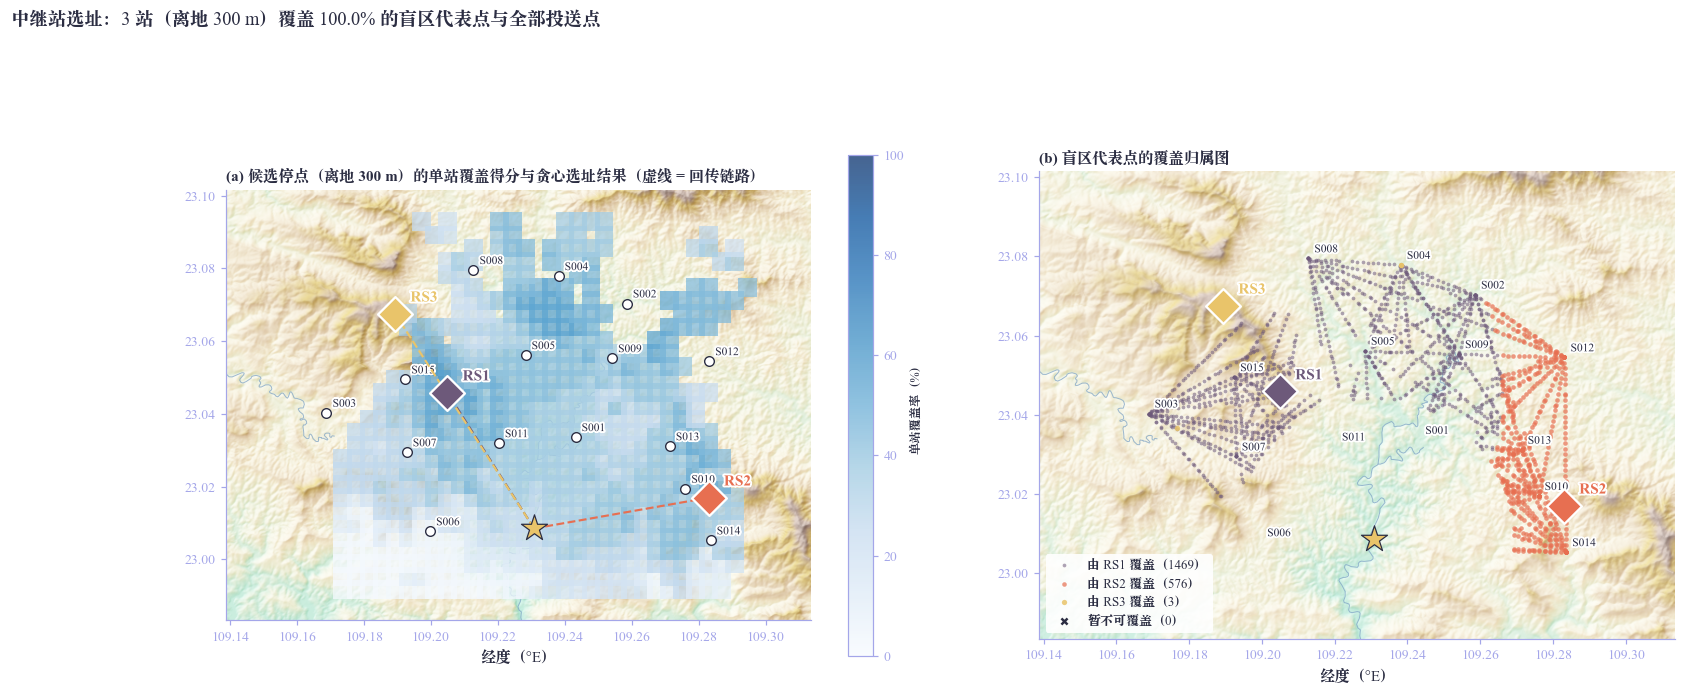

In [7]:
# ---------- 图 3：中继站选址 ----------
fig = plt.figure(figsize=(17, 7.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1.0], wspace=0.12)
ax = fig.add_subplot(gs[0])
base_map(ax)

scorepct = score0 / max(float(w_rep.sum()), 1) * 100
show_cand = scorepct > 0
SC = np.asarray([to_lonlat(x, y) for x, y in CAND[show_cand, :2]])
im = ax.scatter(SC[:, 0], SC[:, 1], c=scorepct[show_cand], s=150, marker='s',
                cmap='Blues', vmin=0, vmax=100, alpha=0.75, linewidths=0, zorder=2)
cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.ax.set_ylabel('单站覆盖率（%）', fontsize=8)
for a in range(1, NN):
    ax.scatter(LONS[a], LATS[a], s=40, facecolor='white',
               edgecolor=PAL['ink'], lw=0.9, zorder=6)
    ax.annotate(NODE_IDS[a], (LONS[a], LATS[a]), xytext=(4, 4),
                textcoords='offset points', fontsize=7.5, path_effects=HALO, zorder=7)
ax.scatter(LONS[0], LATS[0], s=320, marker='*', color=PAL['gold'],
           edgecolor=PAL['ink'], zorder=8)
for n, ll, col in zip(ST_NAMES, ST_LONLAT, ST_COLOR):
    ax.scatter(ll[0], ll[1], s=260, marker='D', color=col,
               edgecolor='white', lw=1.5, zorder=9)
    ax.annotate(n, ll, xytext=(10, 8), textcoords='offset points',
                fontsize=10, fontweight='bold', color=col, path_effects=HALO, zorder=9)
    ax.plot([LONS[0], ll[0]], [LATS[0], ll[1]], color=col, lw=1.4, ls='--', zorder=7)
ax.set_title('(a) 候选停点（离地 300 m）的单站覆盖得分与贪心选址结果（虚线 = 回传链路）',
             loc='left', fontsize=10)
ax.set_xlabel('经度（°E）')

ax = fig.add_subplot(gs[1])
base_map(ax, alpha=0.8)
RLON, RLAT = to_lonlat(REP[:, 0], REP[:, 1])
cov_by = COV[STATIONS].T
seen = np.zeros(len(REP), bool)
for s in range(len(STATIONS)):
    m_s = cov_by[:, s] & ~seen
    seen |= cov_by[:, s]
    ax.scatter(RLON[m_s], RLAT[m_s], s=6 + 3 * s, color=ST_COLOR[s],
               alpha=0.55 + 0.15 * s, lw=0, zorder=3 + s,
               label=f'由 {ST_NAMES[s]} 覆盖（{int(m_s.sum())}）')
mask = ~seen
ax.scatter(RLON[mask], RLAT[mask], s=16, color=PAL['ink'], marker='x',
           zorder=6, label=f'暂不可覆盖（{int(mask.sum())}）')
for n, ll, col in zip(ST_NAMES, ST_LONLAT, ST_COLOR):
    ax.scatter(ll[0], ll[1], s=260, marker='D', color=col,
               edgecolor='white', lw=1.5, zorder=9)
    ax.annotate(n, ll, xytext=(10, 8), textcoords='offset points',
                fontsize=10, fontweight='bold', color=col, path_effects=HALO, zorder=9)
ax.scatter(LONS[0], LATS[0], s=320, marker='*', color=PAL['gold'],
           edgecolor=PAL['ink'], zorder=8)
for a in range(1, NN):
    ax.annotate(NODE_IDS[a], (LONS[a], LATS[a]), xytext=(4, 4),
                textcoords='offset points', fontsize=7.5, path_effects=HALO, zorder=7)
ax.legend(loc='lower left', fontsize=8.5, frameon=True,
          framealpha=0.9, edgecolor='none')
ax.set_title('(b) 盲区代表点的覆盖归属图', loc='left', fontsize=10)
ax.set_xlabel('经度（°E）')

caption = (f'中继站选址：{len(STATIONS)} 站（离地 300 m）覆盖 '
           f'{covered.mean() * 100:.1f}% 的盲区代表点与全部投送点')
fig.suptitle(caption, x=0.01, ha='left', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
savefig(fig, '图03_中继站选址')
print(caption)
plt.show()


## 10 图 4：一条典型航段的链路剖面

取直连中断比例最高的 O01→S002 航段（往程），上图为地形剖面、飞行包线与三条代表性视线（到 G01 与到中继站），下图为沿航段的直连损耗/接入损耗曲线与预算线：直连损耗在进入地形阴影处跳升 10 dB 并超过预算，而到中继站的接入损耗始终低于预算——这就是“直连断、中继接”的量化依据。

🖼️ 已保存 问题三/图04_典型航段链路剖面.png


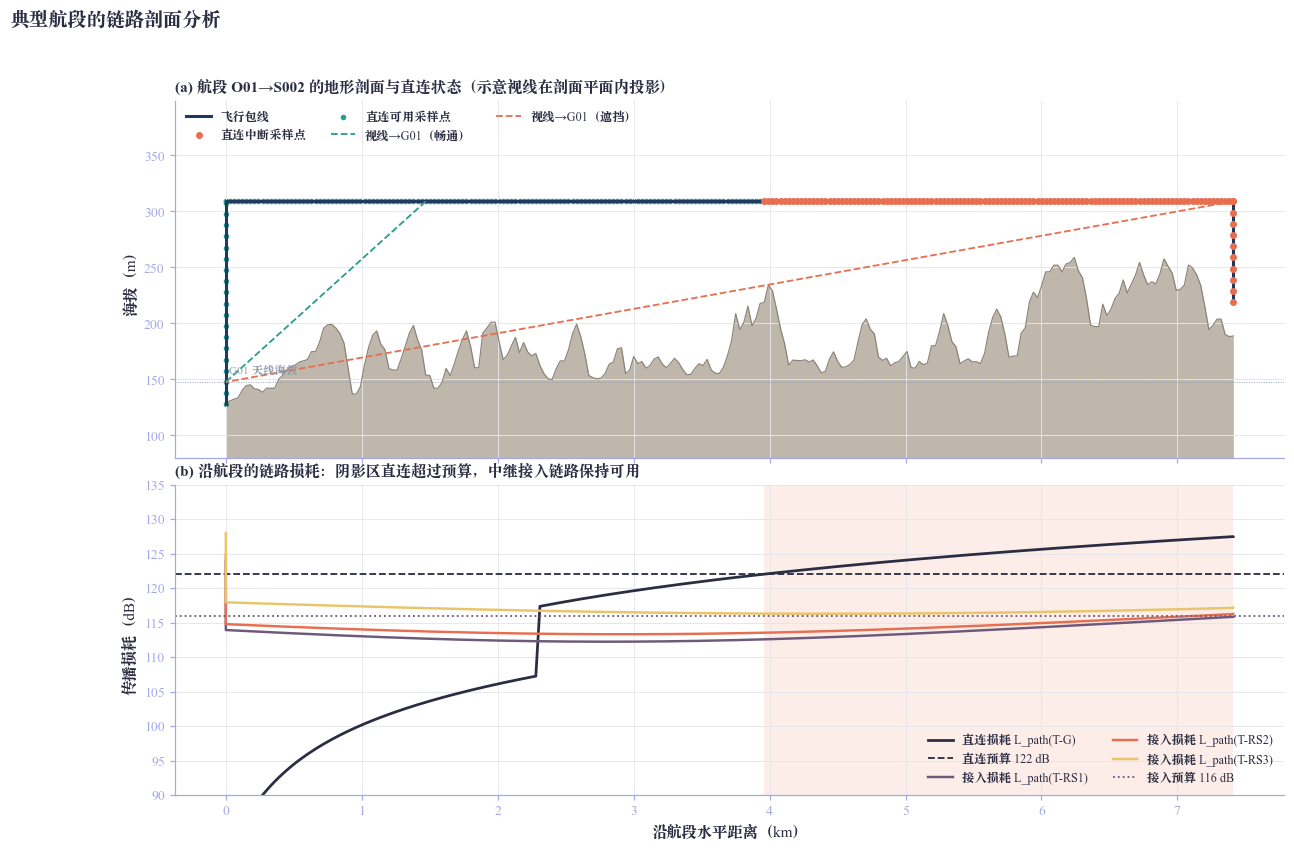

In [8]:
worst = leg_out[leg_out['航段'].str.startswith('O01→')].sort_values('中断比例', ascending=False).iloc[0]['航段']
i_w, i_j = [NODE_IDS.index(s) for s in worst.split('→')]
v = LEG[(i_w, i_j)]; PP = v['P']; d_along = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(PP[:, :2], axis=0), axis=1))]) / 1000
z_ter = dem_at_xy(PP[:, 0], PP[:, 1])
L_dir = path_loss(PP, G01); L_rel = np.column_stack([path_loss(PP, ST_XYZ[s]) for s in range(len(STATIONS))])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8.2), sharex=True, gridspec_kw=dict(height_ratios=[1.15, 1], hspace=0.08))
prof_t = np.linspace(0, 1, 300); px = NX[i_w] + prof_t * (NX[i_j] - NX[i_w]); py = NY[i_w] + prof_t * (NY[i_j] - NY[i_w]); pz = dem_at_xy(px, py)
ax1.fill_between(d_along, 0, z_ter, color=PAL['sand'], alpha=0.9, lw=0); ax1.plot(d_along, z_ter, color='#8C8377', lw=0.8)
cruise = v['phase']; idx_c = [k for k, p in enumerate(cruise) if p == 'cruise']
ax1.plot(d_along, PP[:, 2], color=PAL['indigo'], lw=2.0, label='飞行包线')
ok = v['direct']
ax1.scatter(d_along[~ok], PP[~ok, 2], s=14, color=PAL['coral'], zorder=5, label='直连中断采样点')
ax1.scatter(d_along[ok], PP[ok, 2], s=8, color=PAL['teal'], label='直连可用采样点')
# 三条示意视线（到 G01）：可用、遮挡各取一条；到中继站取一条
for k, col, lab in [(idx_c[len(idx_c) // 5], PAL['teal'], '视线→G01（畅通）'), (idx_c[-1], PAL['coral'], '视线→G01（遮挡）')]:
    dx_km = np.linalg.norm(PP[k, :2] - G01[:2]) / 1000
    ax1.plot([d_along[k], d_along[k] - dx_km], [PP[k, 2], G01[2]], color=col, lw=1.2, ls='--', label=lab)
ax1.axhline(G01[2], color=PAL['grey'], lw=0.6, ls=':')
ax1.text(0.02, G01[2] + 8, 'G01 天线海拔', fontsize=7.5, color=PAL['grey'])
ax1.set_ylabel('海拔（m）')
ax1.set_ylim(80, max(PP[:, 2].max(), pz.max()) + 90)
ax1.legend(loc='upper left', ncol=3, fontsize=8)
ax1.set_title(f'(a) 航段 {worst} 的地形剖面与直连状态（示意视线在剖面平面内投影）', loc='left', fontsize=10)
ax2.plot(d_along, L_dir, color=PAL['ink'], lw=1.8, label='直连损耗 L_path(T-G)')
ax2.axhline(LMAX['T-G'], color=PAL['ink'], lw=1.2, ls='--', label=f'直连预算 {LMAX["T-G"]:.0f} dB')
for s in range(len(STATIONS)):
    ax2.plot(d_along, L_rel[:, s], color=ST_COLOR[s], lw=1.6, label=f'接入损耗 L_path(T-{ST_NAMES[s]})')
ax2.axhline(LMAX['T-R'], color=PAL['plum'], lw=1.2, ls=':', label=f'接入预算 {LMAX["T-R"]:.0f} dB')
ax2.fill_between(d_along, 90, 135, where=~ok, color=PAL['coral'], alpha=0.12, lw=0)
ax2.set_ylim(90, 135)
ax2.set_xlabel('沿航段水平距离（km）')
ax2.set_ylabel('传播损耗（dB）')
ax2.legend(loc='lower right', ncol=2, fontsize=8)
ax2.set_title('(b) 沿航段的链路损耗：阴影区直连超过预算，中继接入链路保持可用', loc='left', fontsize=10)
fig.suptitle('典型航段的链路剖面分析', x=0.01, ha='left', fontsize=12.5, fontweight='bold')
savefig(fig, '图04_典型航段链路剖面'); plt.show()

## 11 时间层 I：航段的“中继服务需求区间”

把每条航段的采样点按机型速度换算成相对航段起点的时间偏移（爬升 $dz/v_{up}$、巡航 $ds/v_c$、下降 $dz/v_{dn}$），把连续的直连中断采样段合并为区间，并为区间指定服务站：同一航段优先使用能覆盖其最多中断点的站，以减少站间切换；投送点的需求区间为 $[t_{到达},t_{离开}]$。这些区间只依赖几何与机型，和架次开始时刻无关，因此可以预先算好，在 ALNS 的每次解码中只做平移与合并。

In [9]:
def leg_intervals(i, j, g):
    """航段 (i, j) 机型 g：返回 [(t0, t1, station)] 相对航段起点的中继需求区间；若存在无法覆盖的中断点返回 None"""
    v = LEG[(i, j)]; p = P[g]; ph = v['phase']; sl = v['seglen']
    dt = np.where(np.array(ph) == 'up', sl / p['v_up'],
                  np.where(np.array(ph) == 'cruise', sl / p['v_c'], sl / p['v_dn']))
    tt = np.cumsum(dt); out = ~v['direct']
    if not out.any(): return []
    if not v['feasible']: return None
    cov = v['cov']; pref = int(np.argmax(cov[out].sum(axis=0)))  # 覆盖本航段中断点最多的站
    st = np.where(cov[:, pref], pref, np.argmax(cov, axis=1))
    ivs = []; k = 0; n = len(out)
    while k < n:
        if out[k]:
            s = st[k]; k0 = k
            while k + 1 < n and out[k + 1] and st[k + 1] == s: k += 1
            t0 = tt[max(k0 - 1, 0)]; t1 = tt[min(k + 1, n - 1)]  # 区间两端各外扩一个采样步
            ivs.append((float(t0), float(t1), int(s)))
        k += 1
    return ivs

P = {g: uav.loc[g] for g in TYPES}
LEG_IV = {(i, j, g): leg_intervals(i, j, g) for (i, j) in LEG for g in TYPES}
HAND_ST = {a: (None if HAND_DIRECT[a] else int(np.argmax(HAND_COV[a]))) for a in range(1, NN)}  # 投送点服务站
n_iv = sum(len(x) for x in LEG_IV.values() if x)
print(f'需求区间预计算完成：{n_iv} 个区间（{len(LEG)} 航段 × {len(TYPES)} 机型），投送点中继保障：' +
      '、'.join(f'{NODE_IDS[a]}→{ST_NAMES[s]}' for a, s in HAND_ST.items() if s is not None))

# 各站到 O01 的往返几何（相同航段规则：沿线最高像元 + 50 m）
def station_leg(s):
    x, y, z = ST_XYZ[s]; lon, lat = ST_LONLAT[s]
    x0, y0 = to_pix(LONS[0], LATS[0]); x1, y1 = to_pix(lon, lat)
    Hc = max(DEM[r, c] for r, c in traverse_cells(x0, y0, x1, y1)) + CLEARANCE
    d = dist_m(LONS[0], LATS[0], lon, lat)
    return dict(d=d, Hc=Hc, z_h=z, up_out=max(0.0, Hc - ALT_OP[0]) + max(0.0, z - Hc),
                dn_out=max(0.0, Hc - z), up_ret=max(0.0, Hc - z),
                dn_ret=max(0.0, Hc - ALT_OP[0]) + max(0.0, z - Hc))

ST_LEG = [station_leg(s) for s in range(len(STATIONS))]

def relay_flight(s):
    """中继机往返站 s 的飞行时间（去、回）与能耗（去、回）"""
    L = ST_LEG[s]
    t_go = L['up_out'] / R['v_up'] + L['d'] / R['v_c'] + L['dn_out'] / R['v_dn']
    t_back = L['up_ret'] / R['v_up'] + L['d'] / R['v_c'] + L['dn_ret'] / R['v_dn']
    e_go = R['P_cruise'] * ((L['d'] / R['v_c']) / 3600) + R['m0'] * G0 * L['up_out'] / (R['eta_up'] * 3.6e6)
    e_back = R['P_cruise'] * ((L['d'] / R['v_c']) / 3600) + R['m0'] * G0 * L['up_ret'] / (R['eta_up'] * 3.6e6)
    return t_go, t_back, e_go, e_back

RELAY_FLIGHT = [relay_flight(s) for s in range(len(STATIONS))]
RELAY_ENDUR = [(R['budget'] - f[2] - f[3] - (R['P_hover'] + R['P_comm']) * R['t_link'] / 3600) /
               (R['P_hover'] + R['P_comm']) * 3600 for f in RELAY_FLIGHT]
for s in range(len(STATIONS)):
    f = RELAY_FLIGHT[s]
    print(f'{ST_NAMES[s]}: 距 O01 {ST_LEG[s]["d"] / 1000:.2f} km，去程 {f[0]:.0f} s / 回程 {f[1]:.0f} s，往返飞行能耗 {f[2] + f[3]:.3f} kWh，0 时刻出发最早建链完成 {R["t_prep"] + f[0] + R["t_link"]:.0f} s，单组件最长在站服务 {RELAY_ENDUR[s] / 3600:.2f} h')

需求区间预计算完成：1296 个区间（240 航段 × 3 机型），投送点中继保障：S002→RS1、S003→RS1、S004→RS3、S005→RS1、S007→RS1、S008→RS1、S009→RS1、S010→RS2、S012→RS2、S013→RS2、S014→RS2、S015→RS1
RS1: 距 O01 4.91 km，去程 485 s / 回程 538 s，往返飞行能耗 0.265 kWh，0 时刻出发最早建链完成 695 s，单组件最长在站服务 2.08 h
RS2: 距 O01 5.43 km，去程 516 s / 回程 568 s，往返飞行能耗 0.286 kWh，0 时刻出发最早建链完成 726 s，单组件最长在站服务 2.06 h
RS3: 距 O01 7.80 km，去程 743 s / 回程 817 s，往返飞行能耗 0.411 kWh，0 时刻出发最早建链完成 953 s，单组件最长在站服务 1.94 h


## 12 模型建立：联合调度

### 12.1 决策结构与通信约束

在问题二整数规划的基础上增加中继站集合 $\mathcal R$、中继架次 $p^R$（含中继机 $r\in\{R01,R02\}$、站点 $s$、服务区间 $[\alpha,\beta]$ 和能源组件 $k$）。对每个运输架次 $p$ 的实际执行区间，必须满足

$$A_p^{TG}(t)=1\quad\text{或}\quad \exists s:\;A_{ps}^{TR}(t)=1\land A_s^{RG}=1\land \text{中继机在站 }s\text{、时刻 }t\text{ 在线}.$$

每个盲区需求区间都须完整落在同站中继会话的服务区间内。中继架次能耗与资源约束为

$$E_p^R=E_{go,s}^{fly}+E_{back,s}^{fly}+(P_{hover}+P_{comm})(t_{link}+\beta-\alpha)/3600\le(1-\rho_R)E_R^{use},$$

同一中继机相邻架次满足 $t_{p}^{st}\ge t_q^{en}+t_{turn}$；能源组件按两阶段充电模型转充完成后才可再次使用。联合完成时间取运输机和中继机返 O01 时刻的最大值。



### 12.2 求解框架：ALNS + 联合列表调度解码

解码器把运输与中继放在同一条时间轴上顺序决策：

1. 运输架次按最迟开始时刻排序，取同型最早可用的无人机与电池得到试探开始时刻 $t^{st}$；
2. 把该架次的中继需求区间平移到绝对时间，逐个向对应中继站“申请保障”：若该站已有一个中继会话（某中继机在站点悬停）且延长其离站时刻后能量仍在预算内，且该中继机没有后续承诺，则延长会话（区间之间的空隙小于“返回 + 周转 + 再去 + 建链”时中继留空悬停，只耗悬停功率）；否则新建会话：选择最早能到位的中继机与最早充好的能源组件，中继机“准时到位”（出发时刻 = 需求开始 − 准备 − 去程 − 建链，避免提前悬停耗能）；
3. 若最早到位时刻晚于需求开始，则把运输架次整体推迟相应时长后重试（最多 6 轮）——这就是“中继先占位，运输随后出发”的规则化实现，也是 3 座中继站共用 2 架中继机时自动错开、兜底任务的机制；
4. 会话结束时刻 = 最后一个需求区间的结束时刻，随后返回 O01；中继机相邻会话之间留出架次周转时间，能源组件按两阶段模型充电后才可再用。

解码得到的方案在构造上满足连续通信与全部中继资源约束（第 20 节仍独立复核）；运输架次因等待中继而产生的推迟由“及时性”与“完成时间”两个指标承担，ALNS 据此权衡“多点串联少用中继”与“多机并行多用中继”。

In [10]:
from collections import Counter
import random

# 货箱与服务区索引（沿用前文的数据顺序）。
AREA_IDX = {a: k + 1 for k, a in enumerate(AREA_IDS)}
NB = len(boxes)
b_id = boxes.box.tolist()
b_area = [AREA_IDX[a] for a in boxes.area]
b_mat = boxes.mat.tolist()
b_mass = boxes.mass.astype(float).tolist()
b_vol = boxes.vol.astype(float).tolist()
b_prio = boxes.priority.astype(float).tolist()
b_texp = boxes.expected.astype(float).tolist()
b_hard = boxes.t_hard.astype(float).tolist()
SUM_PRIO = sum(b_prio)
BOX_IDS = tuple(b_id)
BOX_IDX = {b: i for i, b in enumerate(BOX_IDS)}
BATS = [(bat, g) for g in TYPES for bat in BATTS[g]]
P = {g: uav.loc[g] for g in TYPES}
BUDGET = {g: (1 - P[g].rho) * P[g].E_use for g in TYPES}


def t_chg(s, T_full):
    return T_full * (0.65 * (0.9 - s) / 0.9 + 0.35) if s < 0.9 else T_full * 0.35 * (1 - s) / 0.1


def t_chg_r(s):
    return t_chg(max(s, 0.0), T_FULL_R)


P_SVC = R['P_hover'] + R['P_comm']  # 在站功率（kW）
T_GO = [R['t_prep'] + f[0] + R['t_link'] for f in RELAY_FLIGHT]  # 出发至建链完成时间


def eval_sortie(g, stops):
    """stops: [[area_idx, [box_idx, ...]], ...] → 物理量与相对中继需求区间，或 None。"""
    p = P[g]
    mass = 0.0
    vol = 0.0
    n = 0
    relay = []
    for a, bl in stops:
        for b in bl:
            mass += b_mass[b]
            vol += b_vol[b]
            n += 1
    if n == 0 or mass > p['Q'] + 1e-9 or vol > p['V'] + 1e-9:
        return None

    t = p['t_prep'] + p['t_load'] * n
    E = 0.0
    q = mass
    prev = 0
    deliv = []
    segs = [('prep', 0.0, t, 0)]
    legs = []
    LT, LA, LB = LEG_T[g], LEG_A[g], LEG_B[g]
    for a, bl in stops:
        iv = LEG_IV[(prev, a, g)]
        if iv is None or not HAND_FEAS[a]:
            return None
        for t0, t1, station in iv:
            relay.append((t + t0, t + t1, station))
        e = LA[prev][a] / L_eq(p, q) + (p['m0'] + q) * LB[prev][a]
        E += e
        t1 = t + LT[prev][a]
        segs.append(('fly', t, t1, a))
        legs.append((prev, a, e))
        t = t1
        t0 = t + p['t_hand']
        tt = t0
        for b in sorted(bl, key=lambda b: (b_hard[b], -b_prio[b])):
            tt += p['t_box']
            deliv.append((b, tt))
        if HAND_ST[a] is not None:
            relay.append((t0, tt, HAND_ST[a]))
        segs.append(('hand', t, tt, a))
        t = tt
        for b in bl:
            q -= b_mass[b]
        prev = a

    iv = LEG_IV[(prev, 0, g)]
    if iv is None:
        return None
    for t0, t1, station in iv:
        relay.append((t + t0, t + t1, station))
    e = LA[prev][0] / L_eq(p, 0.0) + p['m0'] * LB[prev][0]
    E += e
    t1 = t + LT[prev][0]
    segs.append(('fly', t, t1, 0))
    legs.append((prev, 0, e))
    t = t1
    if E > BUDGET[g] + 1e-9:
        return None
    relay.sort()
    return dict(E=E, dur=t, deliv=deliv, mass=mass, vol=vol, n=n,
                segs=segs, legs=legs, relay=relay)


class Sortie:
    __slots__ = ('g', 'stops', 'ev', 'key')

    def __init__(self, g, stops):
        self.g = g
        self.stops = stops
        self.refresh()

    def refresh(self):
        self.ev = eval_sortie(self.g, self.stops)
        if self.ev:
            self.key = (min(b_hard[b] - off for b, off in self.ev['deliv']),
                        min(b_texp[b] - off for b, off in self.ev['deliv']))
        else:
            self.key = (math.inf, math.inf)
        return self

    def copy(self):
        return Sortie(self.g, [[a, list(bl)] for a, bl in self.stops])

    def route(self):
        return 'O01→' + '→'.join(NODE_IDS[a] for a, _ in self.stops) + '→O01'

    def box_ids(self):
        return tuple(b for _, bl in self.stops for b in bl)


class RelayState:
    """中继资源状态：中继机可出发时刻、能源组件可用时刻及在站会话。"""
    def __init__(self):
        self.r_av = {r: 0.0 for r in RELAYS}
        self.c_av = {c: 0.0 for c in COMPS}
        self.sess = []
        self.last = {r: None for r in RELAYS}

    def copy(self):
        out = RelayState()
        out.r_av = dict(self.r_av)
        out.c_av = dict(self.c_av)
        out.sess = [dict(s, demands=list(s.get('demands', []))) for s in self.sess]
        out.last = dict(self.last)
        return out

    def energy(self, s, t_leave):
        f = RELAY_FLIGHT[s['station']]
        return f[2] + f[3] + P_SVC * (R['t_link'] + (t_leave - s['t_linked'])) / 3600

    def _commit_times(self, s):
        f = RELAY_FLIGHT[s['station']]
        s['depart'] = s['t_dep']
        s['linked'] = s['t_linked']
        s['service_start'] = s['t_linked']
        s['service_end'] = s['t_leave']
        s['return'] = s['t_end'] = s['t_leave'] + f[1]
        s['E'] = self.energy(s, s['t_leave'])
        s['soc'] = 1 - s['E'] / R['E_use']
        s['comp_ready'] = s['return'] + t_chg_r(s['soc'])
        self.r_av[s['relay']] = s['return'] + R['t_turn']
        self.c_av[s['comp']] = s['comp_ready']

    def serve(self, station, A, B, commit=True, owner=None):
        """保障 station 在 [A,B] 在线；返回所需运输推迟（0 表示可保障）。"""
        # 1) 尝试延长同站会话；只有该中继机最近的会话允许延长。
        for si, s in enumerate(self.sess):
            if s['station'] == station and s['t_linked'] <= A + 1e-9 and self.last[s['relay']] == si:
                gap_ok = A <= s['t_leave'] + RELAY_FLIGHT[station][1] + R['t_turn'] + T_GO[station]
                new_leave = max(s['t_leave'], B)
                if gap_ok and self.energy(s, new_leave) <= R['budget'] + 1e-9:
                    if commit:
                        s['t_leave'] = new_leave
                        s.setdefault('demands', []).append((A, B, owner))
                        self._commit_times(s)
                    return 0.0

        # 2) 新会話：取最早可到位的中继机与已充好的能源组件。
        best = None
        for r in RELAYS:
            c = min(COMPS, key=lambda x: self.c_av[x])
            t_dep = max(self.r_av[r], self.c_av[c])
            t_link = t_dep + T_GO[station]
            if best is None or t_link < best[0]:
                best = (t_link, r, c, t_dep)
        t_link, r, c, t_dep = best
        if t_link > A + 1e-6:
            return t_link - A
        if B - A + R['t_link'] > RELAY_ENDUR[station] + R['t_link'] + 1e-6:
            return math.inf
        t_dep = max(t_dep, A - T_GO[station])  # 准时到位，不提前悬停耗能
        s = dict(relay=r, comp=c, station=station, t_dep=t_dep,
                 t_linked=t_dep + T_GO[station], t_leave=max(B, t_dep + T_GO[station]),
                 service_start=t_dep + T_GO[station], service_end=max(B, t_dep + T_GO[station]),
                 demands=[(A, B, owner)])
        if self.energy(s, s['t_leave']) > R['budget'] + 1e-9:
            return math.inf
        if commit:
            self.sess.append(s)
            self.last[r] = len(self.sess) - 1
            self._commit_times(s)
        return 0.0


def _empty_metrics():
    return dict(tard=0.0, wdt=0.0, hard_h=0.0, hard_n=0, makespan=0.0,
                makespan_T=0.0, makespan_R=0.0, E=0.0, E_T=0.0, E_R=0.0,
                N=0, N_T=0, N_R=0, outage_h=0.0, outage_n=0,
                relay=[], relay_delay=0.0, sched=[], tdel=[None] * NB, order=[])


def decode(sorties, order=None):
    """联合列表调度解码：运输占用、电池充电与中继会话同步排程。"""
    sorties = list(sorties)
    if not sorties:
        return None
    all_ids = [b for s in sorties for b in s.box_ids()]
    if len(all_ids) != len(set(all_ids)):
        return None
    if any(s.ev is None for s in sorties):
        return None
    if order is None:
        order = sorted(range(len(sorties)), key=lambda k: sorties[k].key)
    else:
        order = list(order)
    if sorted(order) != list(range(len(sorties))):
        return None

    uav_av = {u: 0.0 for u, _ in UAVS}
    bat_av = {b: 0.0 for b, _ in BATS}
    sched = [None] * len(sorties)
    tdel = [None] * NB
    RS = RelayState()
    relay_delay = 0.0

    for k in order:
        s = sorties[k]
        g, ev = s.g, s.ev
        u = min((uu for uu, gg in UAVS if gg == g), key=lambda x: uav_av[x])
        b = min((bb for bb, gg in BATS if gg == g), key=lambda x: bat_av[x])
        st0 = max(uav_av[u], bat_av[b])
        st = st0
        for _ in range(6):
            trial = RS.copy()
            delay = 0.0
            for a, bb, sidx in ev['relay']:
                d = trial.serve(sidx, st + a, st + bb, commit=True, owner=k)
                if d > 0:
                    delay = max(delay, d)
            if delay <= 1e-7:
                RS = trial
                break
            if not np.isfinite(delay):
                return None
            st += delay
        else:
            return None
        relay_delay += st - st0
        en = st + ev['dur']
        soc = 1 - ev['E'] / P[g]['E_use']
        ready = en + t_chg(soc, BATT[g][1])
        sched[k] = (u, b, st, en, soc)
        uav_av[u] = en
        bat_av[b] = ready
        for bx, off in ev['deliv']:
            tdel[bx] = st + off

    tard = wdt = hard_h = 0.0
    hard_n = 0
    for bx, t in enumerate(tdel):
        if t is None:
            continue
        tard += b_prio[bx] * max(0.0, t - b_texp[bx])
        wdt += b_prio[bx] * t
        if t > b_hard[bx] + 1e-6:
            hard_h += (t - b_hard[bx]) / 3600
            hard_n += 1

    makespan_T = max(x[3] for x in sched if x is not None)
    makespan_R = max((s['t_end'] for s in RS.sess), default=0.0)
    E_R = sum(s['E'] for s in RS.sess)
    E_T = sum(s.ev['E'] for s in sorties)
    ready_by_k = []
    for k, s in enumerate(sorties):
        _, b, _, en, soc = sched[k]
        ready_by_k.append(en + t_chg(soc, BATT[s.g][1]))
    schedule = tuple((*row, ready_by_k[k]) for k, row in enumerate(sched))
    m = dict(tard=tard / SUM_PRIO, wdt=wdt / SUM_PRIO, hard_h=hard_h, hard_n=hard_n,
             makespan=max(makespan_T, makespan_R), makespan_T=makespan_T, makespan_R=makespan_R,
             E=E_T + E_R, E_T=E_T, E_R=E_R, N=len(sorties) + len(RS.sess),
             N_T=len(sorties), N_R=len(RS.sess), outage_h=0.0, outage_n=0,
             relay=RS.sess, relay_delay=relay_delay, sched=tuple(sched), tdel=tuple(tdel), order=order)
    # 后续结果表、通信图与独立复核沿用的字段名。
    m.update(T=(m['tard'] + 0.1 * m['wdt']) / 3600, avg_delay=m['tard'], avg_arrival=m['wdt'],
             M=m['makespan'], transport_M=makespan_T, transport_E=E_T, transport_N=len(sorties),
             relay_E=E_R, relay_N=len(RS.sess), relay_M=makespan_R, relay_wait=relay_delay,
             hard_sum=hard_h * 3600, hard_max=hard_h * 3600,
             schedule=schedule, arrival=np.asarray([np.nan if t is None else t for t in tdel]),
             relay_sessions=RS.sess)
    return m


W_REC = dict(T=3.0, M=1.5, E=1.0, N=0.5)


def objective(m, W):
    if m is None:
        return math.inf
    return (W['T'] * (m['tard'] + 0.1 * m['wdt']) / 3600
            + W['M'] * m['makespan'] / 3600
            + W['E'] * m['E'] / 50
            + W['N'] * m['N'] / 20
            + 100 * m['hard_h'] + 5 * m['hard_n']
            + 100 * m['outage_h'] + 5 * m['outage_n'])


def metrics_row(m):
    return dict(及时性T=(m['tard'] + 0.1 * m['wdt']) / 3600,
                加权平均迟到_s=m['tard'], 加权平均送达_s=m['wdt'],
                联合完成时间_h=m['makespan'] / 3600,
                运输完成时间_h=m['makespan_T'] / 3600,
                总能耗_kWh=m['E'], 运输能耗_kWh=m['E_T'], 中继能耗_kWh=m['E_R'],
                运输架次=m['N_T'], 中继架次=m['N_R'], 硬时限违约箱=m['hard_n'],
                中继等待总延迟_s=m['relay_delay'])


print('联合模型已定义：eval_sortie（含通信需求区间）、RelayState（中继会话）、decode（联合列表调度）、objective（联合目标）')

联合模型已定义：eval_sortie（含通信需求区间）、RelayState（中继会话）、decode（联合列表调度）、objective（联合目标）


## 13 求解算法：ALNS（与问题二相同的算子与接受准则，目标换成联合目标）

破坏 / 修复算子、代理插入代价、停滞顺序枚举、机型互换、模拟退火与自适应权重均与问题二一致；差别只在：架次评估器会拒绝通信不可行航段，解码器内嵌中继解码，目标含中继能耗/架次与通信中断项。以问题二风格的单点架次初始化，8000 次迭代 + 顺序精修。



In [11]:
D_NAMES = ['随机移除', '最晚送达移除', '同区移除', '整架次移除', '末班架次移除']
R_NAMES = ['贪心插入', '贪心+噪声插入']


def initial_solution():
    """逐服务区按 C→B→A 依次装满（问题二风格的单点架次），仅保证可行。"""
    sorties = []
    for a in range(1, NN):
        bl = sorted([b for b in range(NB) if b_area[b] == a],
                    key=lambda b: (b_hard[b], -b_mass[b]))
        while bl:
            for g in ['C', 'B', 'A']:
                cur = []
                for b in bl:
                    if eval_sortie(g, [[a, cur + [b]]]) is not None:
                        cur.append(b)
                if cur:
                    sorties.append(Sortie(g, [[a, cur]]))
                    bl = [b for b in bl if b not in cur]
                    break
            else:
                raise RuntimeError('初始解构造失败')
    return sorties


def insertion_best(sol, b, est_start, W, noise, rng):
    a = b_area[b]
    best = (math.inf, None)

    def penal(st0, ev):
        c = 0.0
        for bx, off in ev['deliv']:
            if st0 + off > b_hard[bx]:
                c += 100 * (st0 + off - b_hard[bx]) / 3600 + 5
        return c

    for k, s in enumerate(sol):
        old = s.ev
        areas_in = [st[0] for st in s.stops]
        cand_stops = []
        if a in areas_in:
            j = areas_in.index(a)
            stops = [[x, list(bl)] for x, bl in s.stops]
            stops[j][1].append(b)
            cand_stops.append(stops)
        else:
            for pos in range(len(s.stops) + 1):
                stops = [[x, list(bl)] for x, bl in s.stops]
                stops.insert(pos, [a, [b]])
                cand_stops.append(stops)
        for stops in cand_stops:
            ev = eval_sortie(s.g, stops)
            if ev is None:
                continue
            c = (W['E'] * (ev['E'] - old['E']) / 50
                 + W['M'] * (ev['dur'] - old['dur']) / 3600
                 + penal(est_start[k], ev))
            if noise:
                c *= rng.uniform(0.85, 1.15)
            if c < best[0]:
                best = (c, (k, stops))

    for g in TYPES:
        ev = eval_sortie(g, [[a, [b]]])
        if ev is None:
            continue
        c = (W['E'] * ev['E'] / 50 + W['M'] * ev['dur'] / 3600
             + W['N'] / 20 + penal(est_start[('new', g)], ev))
        if noise:
            c *= rng.uniform(0.85, 1.15)
        if c < best[0]:
            best = (c, ('new', g, [[a, [b]]]))
    return best


def reorder_stops(s):
    if len(s.stops) <= 1 or len(s.stops) > 5:
        return
    best = None
    for perm in itertools.permutations(s.stops):
        ev = eval_sortie(s.g, perm)
        if ev is None:
            continue
        score = ev['E'] / 50 + ev['dur'] / 3600
        if best is None or score < best[0]:
            best = (score, perm)
    if best:
        s.stops = [[a, list(bl)] for a, bl in best[1]]
        s.refresh()


def run_alns(sol, W, iters=8000, seed=0, W_track=None):
    """W_track：额外指定一组权重跟踪搜索过程中遇到的最优解（用于把推荐权重的搜索结果回馈给搜索）。"""
    rng = random.Random(seed)
    cur = [s.copy() for s in sol]
    cur_m = decode(cur)
    cur_f = objective(cur_m, W)
    best = [s.copy() for s in cur]
    best_f, best_m = cur_f, cur_m
    track = (objective(cur_m, W_track), [s.copy() for s in cur], cur_m) if W_track else None

    dw = [1.0] * 5
    rw = [1.0] * 2
    ds = [0.0] * 5
    rs = [0.0] * 2
    dcnt = [0] * 5
    rcnt = [0] * 2
    F_ref = objective(dict(cur_m, hard_h=0.0, hard_n=0, outage_h=0, outage_n=0), W)
    T = 0.05 * F_ref
    T_end = 0.005 * F_ref
    alpha = (T_end / T) ** (1 / iters)
    hist = []
    whist = [(0, list(dw))]
    explored = []

    for it in range(iters):
        sched = cur_m['sched']
        est = {k: sched[k][2] for k in range(len(cur))}
        uav_av = {u: 0.0 for u, _ in UAVS}
        for u, b, st, en, soc in sched:
            uav_av[u] = max(uav_av[u], en)
        for g in TYPES:
            est[('new', g)] = min(uav_av[u] for u, gg in UAVS if gg == g)

        di = rng.choices(range(5), weights=dw, k=1)[0]
        ri = rng.choices(range(2), weights=rw, k=1)[0]
        new = [s.copy() for s in cur]
        nrem = rng.randint(4, 12)
        allb = range(NB)
        if di == 0:
            removed = rng.sample(list(allb), nrem)
        elif di == 1:
            removed = sorted(allb, key=lambda b: -(b_prio[b] * (cur_m['tdel'][b] - b_texp[b])
                              + (1e6 if cur_m['tdel'][b] > b_hard[b] else 0)))[:nrem]
        elif di == 2:
            a = rng.randint(1, NN - 1)
            removed = [b for b in allb if b_area[b] == a]
        elif di == 3:
            s = rng.choice(new)
            removed = [b for _, l in s.stops for b in l]
        else:
            k = max(range(len(new)), key=lambda k: sched[k][3])
            removed = [b for _, l in new[k].stops for b in l]

        rem = set(removed)
        for s in new:
            s.stops = [[a, [b for b in bl if b not in rem]] for a, bl in s.stops]
            s.stops = [st for st in s.stops if st[1]]
        new = [s for s in new if s.stops]
        for s in new:
            s.refresh()

        pm = decode(new) if new else None
        est2 = {k: (pm['sched'][k][2] if pm is not None else 0.0) for k in range(len(new))}
        for g in TYPES:
            est2[('new', g)] = est[('new', g)]

        removed.sort(key=lambda b: (b_hard[b], -b_mass[b]))
        for b in removed:
            _, act = insertion_best(new, b, est2, W, ri == 1, rng)
            if act is None:
                raise RuntimeError('無可行插入位置')
            if act[0] == 'new':
                new.append(Sortie(act[1], act[2]))
                est2[len(new) - 1] = est[('new', act[1])]
            else:
                k, stops = act
                new[k].stops = stops
                new[k].refresh()
        for s in new:
            reorder_stops(s)
        if new and rng.random() < 0.2:
            s = rng.choice(new)
            for g in rng.sample(TYPES, len(TYPES)):
                if g != s.g and eval_sortie(g, s.stops) is not None:
                    s.g = g
                    s.refresh()
                    break
        nm = decode(new)
        if nm is None:
            nf = math.inf
        else:
            nf = objective(nm, W)
            if nm['hard_n'] == 0 and W_track:
                ft = objective(nm, W_track)
                if track is None or ft < track[0] - 1e-9:
                    track = (ft, [s.copy() for s in new], nm)

        score = 0
        if nm is not None and nf < best_f - 1e-9:
            best = [s.copy() for s in new]
            best_f, best_m = nf, nm
            score = 3
        if nm is not None and (nf < cur_f - 1e-9 or rng.random() < math.exp(-(nf - cur_f) / max(T, 1e-12))):
            if score == 0:
                score = 2 if nf < cur_f else 1
            cur, cur_m, cur_f = [s.copy() for s in new], nm, nf
            if nm['hard_n'] == 0:
                explored.append(((nm['tard'] + 0.1 * nm['wdt']) / 3600,
                                 nm['makespan'] / 3600, nm['E'], nm['N']))
        ds[di] += score
        rs[ri] += score
        dcnt[di] += 1
        rcnt[ri] += 1

        if (it + 1) % 100 == 0:
            for i in range(5):
                if dcnt[i]:
                    dw[i] = max(0.05, 0.5 * dw[i] + 0.5 * ds[i] / dcnt[i])
            for i in range(2):
                if rcnt[i]:
                    rw[i] = max(0.05, 0.5 * rw[i] + 0.5 * rs[i] / rcnt[i])
            ds, rs = [0.0] * 5, [0.0] * 2
            dcnt, rcnt = [0] * 5, [0] * 2
            whist.append((it + 1, list(dw)))
        T *= alpha
        hist.append((it + 1, cur_f, best_f, best_m['makespan'], best_m['E'], best_m['N'],
                     (best_m['tard'] + 0.1 * best_m['wdt']) / 3600, best_m['hard_n']))

    return best, best_m, best_f, hist, whist, explored, track


def polish_order(sol, W, trials=400, seed=1):
    """第二阶段：固定组批与路线，仅对解码器的排序顺序做交换局部搜索。"""
    rng = random.Random(seed)
    order = sorted(range(len(sol)), key=lambda k: sol[k].key)
    m = decode(sol, order)
    f = objective(m, W)
    if len(order) < 2:
        return order, m, f
    for _ in range(trials):
        i, j = rng.sample(range(len(order)), 2)
        cand = list(order)
        cand[i], cand[j] = cand[j], cand[i]
        mm = decode(sol, cand)
        ff = objective(mm, W)
        if ff < f - 1e-9:
            order, m, f = cand, mm, ff
    return order, m, f


print('ALNS 已定义。')

ALNS 已定义。


## 14 求解推荐方案与权衡情景（权重 (3,1.5,1,0.5))

主搜索 8000 次迭代后，四组权重情景各 2500 次热启动搜索并按推荐权重回收沿途最优解，最终推荐方案取推荐权重下最优者。图 5 记录主搜索的收敛过程。


初始解：运输 18 架次 + 中继 6 架次，联合完成时间 5.18 h，硬时限违约 23 箱，中继推迟合计 2 min
ALNS 8000 次迭代用时 59.0 s：F=7.198
顺序精修后 F=7.053：及时性T=0.178，加权平均迟到_s=248.485，加权平均送达_s=3905.326，联合完成时间_h=2.828，运输完成时间_h=2.797，总能耗_kWh=81.470，运输能耗_kWh=76.134，中继能耗_kWh=5.336，运输架次=21，中继架次=5，硬时限违约箱=0，中继等待总延迟_s=13749.342
及时性优先：及时性T=0.131，加权平均迟到_s=111.870，加权平均送达_s=3614.009，联合完成时间_h=2.819，运输完成时间_h=2.786，总能耗_kWh=81.767，运输能耗_kWh=76.943，中继能耗_kWh=4.824，运输架次=24，中继架次=4，硬时限违约箱=0，中继等待总延迟_s=8375.167
完成时间优先：及时性T=0.232，加权平均迟到_s=423.459，加权平均送达_s=4124.058，联合完成时间_h=2.750，运输完成时间_h=2.701，总能耗_kWh=88.799，运输能耗_kWh=84.188，中继能耗_kWh=4.611，运输架次=24，中继架次=4，硬时限违约箱=0，中继等待总延迟_s=6315.430
能耗优先：及时性T=0.301，加权平均迟到_s=633.851，加权平均送达_s=4481.465，联合完成时间_h=3.016，运输完成时间_h=2.964，总能耗_kWh=75.718，运输能耗_kWh=70.680，中继能耗_kWh=5.037，运输架次=20，中继架次=4，硬时限违约箱=0，中继等待总延迟_s=5868.712
架次优先：及时性T=0.307，加权平均迟到_s=636.102，加权平均送达_s=4702.987，联合完成时间_h=3.709，运输完成时间_h=3.675，总能耗_kWh=79.401，运输能耗_kWh=73.222，中继能耗_kWh=6.179，运输架次=17，中继架次=5，硬时限违约箱=0，中继等待总延迟_s=7486.803
权衡情景求解用时 75.8 s
→ 最终推荐方案来自「及时性优先情景跟踪」，F=6.957

,T,M,E,N,及时性T,加权平均迟到_s,加权平均送达_s,联合完成时间_h,运输完成时间_h,总能耗_kWh,运输能耗_kWh,中继能耗_kWh,运输架次,中继架次,硬时限违约箱,中继等待总延迟_s,机型构成
情景,,,,,,,,,,,,,,,,,
"推荐 (3, 1.5, 1, 0.5)",3.00,1.50,1.00,0.50,0.134,119.303,3617.919,2.819,2.786,81.371,76.404,4.967,24,4,0,7262.900,"{'C': 6, 'B': 7, 'A': 11}"
及时性优先,8.00,1.00,0.50,0.25,0.131,111.870,3614.009,2.819,2.786,81.767,76.943,4.824,24,4,0,8375.167,"{'C': 6, 'B': 6, 'A': 12}"
完成时间优先,1.00,6.00,0.50,0.25,0.232,423.459,4124.058,2.750,2.701,88.799,84.188,4.611,24,4,0,6315.430,"{'C': 7, 'B': 5, 'A': 12}"
能耗优先,1.00,0.50,6.00,0.50,0.301,633.851,4481.465,3.016,2.964,75.718,70.680,5.037,20,4,0,5868.712,"{'C': 7, 'B': 10, 'A': 3}"
架次优先,1.00,0.50,1.00,6.00,0.307,636.102,4702.987,3.709,3.675,79.401,73.222,6.179,17,5,0,7486.803,"{'C': 9, 'B': 4, 'A': 4}"


记录到 2301 个互不相同的可行解（硬时限与通信均满足），四维非支配解 69 个
🖼️ 已保存 问题三/图05_ALNS搜索过程.png


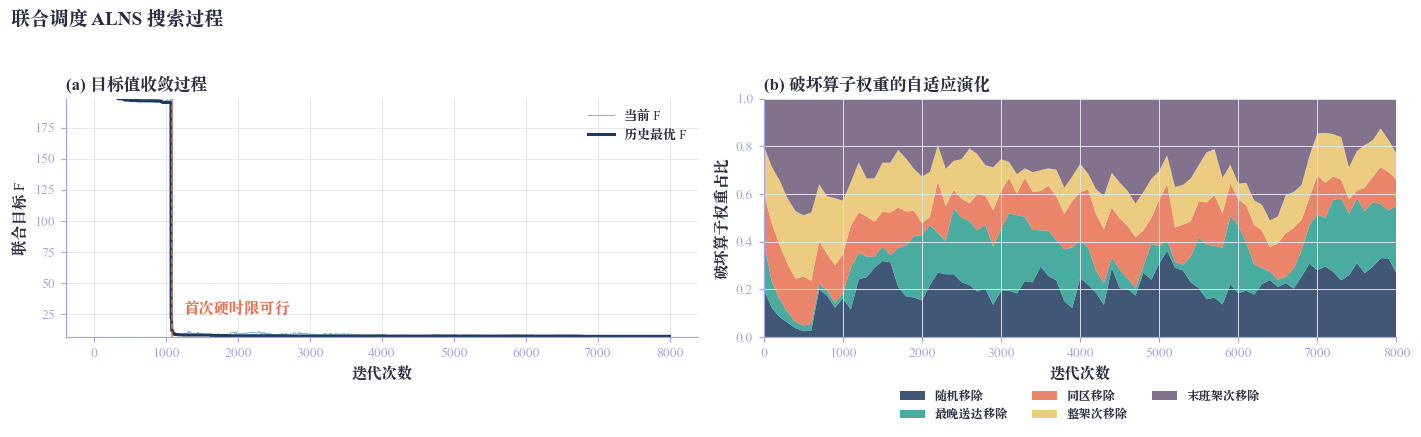

In [12]:
ITERS_MAIN, ITERS_SCEN = 8000, 2500

t0 = time.time()
sol0 = initial_solution()
m_init = decode(sol0)
print(f"初始解：运输 {m_init['N_T']} 架次 + 中继 {m_init['N_R']} 架次，联合完成时间 {m_init['makespan']/3600:.2f} h，硬时限违约 {m_init['hard_n']} 箱，中继推迟合计 {m_init['relay_delay']/60:.0f} min")

best, best_m, best_f, HIST, WHIS, EXPL, _ = run_alns(sol0, W_REC, iters=ITERS_MAIN, seed=2026)
t1 = time.time()
print(f"ALNS {ITERS_MAIN} 次迭代用时 {t1-t0:.1f} s：F={best_f:.3f}")
ORDER, best_m, best_f = polish_order(best, W_REC)
MAIN_SOL, MAIN_M, MAIN_F = best, best_m, best_f
print('顺序精修后 F={:.3f}：'.format(MAIN_F) + '，'.join(f'{k}={v:.3f}' if isinstance(v, float) else f'{k}={v}' for k, v in metrics_row(MAIN_M).items()))

SCEN_W = {
    '及时性优先': dict(T=8.0, M=1.0, E=0.5, N=0.25),
    '完成时间优先': dict(T=1.0, M=6.0, E=0.5, N=0.25),
    '能耗优先': dict(T=1.0, M=0.5, E=6.0, N=0.5),
    '架次优先': dict(T=1.0, M=0.5, E=1.0, N=6.0),
}
scen_sol = {}
explored_all = list(EXPL)
cands = [(MAIN_F, MAIN_SOL, MAIN_M, '主搜索')]
t0 = time.time()
for k, (name, w) in enumerate(SCEN_W.items()):
    sol, m, f, h, wh, ex, track = run_alns(MAIN_SOL, w, iters=ITERS_SCEN,
                                           seed=7 + k, W_track=W_REC)
    _, m, f = polish_order(sol, w, trials=200)
    explored_all += ex
    scen_sol[name] = (sol, m)
    cands.append((objective(m, W_REC), sol, m, name))
    if track:
        _, tm, tf = polish_order(track[1], W_REC, trials=2000)
        cands.append((tf, track[1], tm, f'{name}情景跟踪'))
    print(f"{name}：" + '，'.join(f'{kk}={vv:.3f}' if isinstance(vv, float) else f'{kk}={vv}' for kk, vv in metrics_row(m).items()))
print(f'权衡情景求解用时 {time.time()-t0:.1f} s')

cands.sort(key=lambda x: x[0])
PLAN_F, PLAN_SORTIES, PLAN_M, PLAN_SRC = cands[0]
print(f'→ 最终推荐方案来自「{PLAN_SRC}」，F={PLAN_F:.3f}：' +
      '，'.join(f'{kk}={vv:.3f}' if isinstance(vv, float) else f'{kk}={vv}' for kk, vv in metrics_row(PLAN_M).items()))

SCEN = {'推荐 (3, 1.5, 1, 0.5)': (W_REC, PLAN_SORTIES, PLAN_M)}
SCEN.update({name: (SCEN_W[name], sol, m) for name, (sol, m) in scen_sol.items()})
scen_rows = []
for name, (w, sol, m) in SCEN.items():
    row = dict(情景=name, **{k: f'{v:.2f}' for k, v in w.items()})
    row.update(metrics_row(m))
    row['机型构成'] = dict(Counter(s.g for s in sol))
    scen_rows.append(row)
scen_df = pd.DataFrame(scen_rows).set_index('情景')
display(scen_df.round(3))
# 后续权衡图使用的列名兼容。
scen_df['及时性'] = scen_df['及时性T']

pts = np.array(sorted(set(explored_all)))
nd = np.ones(len(pts), dtype=bool)
for i in range(len(pts)):
    if nd[i]:
        dom = np.all(pts <= pts[i] + 1e-9, axis=1) & np.any(pts < pts[i] - 1e-9, axis=1)
        if dom.any():
            nd[i] = False
nd_df = pd.DataFrame(pts[nd], columns=['及时性T', '联合完成时间_h', '总能耗_kWh', '总架次']).sort_values('联合完成时间_h')
print(f'记录到 {len(pts)} 个互不相同的可行解（硬时限与通信均满足），四维非支配解 {int(nd.sum())} 个')

# 图 5：主搜索目标收敛与破坏算子权重自适应过程。
H = np.array([(h[0], h[1], h[2], h[3], h[4], h[5], h[6]) for h in HIST])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
y_lo = H[:, 2].min() * 0.92
y_hi = np.percentile(H[200:, 1], 97)
ax.plot(H[:, 0], H[:, 1], color=PAL['sky'], lw=0.7, label='当前 F')
ax.plot(H[:, 0], H[:, 2], color=PAL['indigo'], lw=2.0, label='历史最优 F')
first_feas = next((h[0] for h in HIST if h[7] == 0), None)
if first_feas is not None:
    ax.axvline(first_feas, color=PAL['coral'], ls='--', lw=1)
    ax.text(first_feas + ITERS_MAIN * 0.02, y_lo + 0.1 * (y_hi - y_lo), '首次硬时限可行', color=PAL['coral'])
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel('迭代次数')
ax.set_ylabel('联合目标 F')
ax.legend(loc='upper right')
ax.set_title('(a) 目标值收敛过程', loc='left')
ax = axes[1]
wt = np.asarray([w for _, w in WHIS], dtype=float)
wt = wt / wt.sum(axis=1, keepdims=True)
ax.stackplot([it for it, _ in WHIS], wt.T, labels=D_NAMES,
             colors=[PAL['indigo'], PAL['teal'], PAL['coral'], PAL['gold'], PAL['plum']], alpha=0.85)
ax.set_xlim(0, ITERS_MAIN)
ax.set_ylim(0, 1)
ax.set_xlabel('迭代次数')
ax.set_ylabel('破坏算子权重占比')
ax.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, -0.18), fontsize=8)
ax.set_title('(b) 破坏算子权重的自适应演化', loc='left')
fig.suptitle('联合调度 ALNS 搜索过程', x=0.01, ha='left', fontsize=12.5, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
savefig(fig, '图05_ALNS搜索过程')
plt.show()

## 15 推荐方案的结果表：运输架次、中继架次、逐箱送达与通信状态

运输架次表与问题二同构；中继架次表给出每架次的中继机、能源组件、服务站、出发/建链/离站/返航时刻、能耗与结束 SOC；通信状态表按每架运输架次统计直连 / 中继 / 中断时长（以 5 s 步长对轨迹重新采样，独立于解码器判定）。



In [13]:
# 截图中称为 t_ch；本 Notebook 前文对应函数名为 t_chg。
t_ch = t_chg

def build_tables(sorties,m):
    sched=m['schedule']
    seq=sorted(range(len(sorties)),key=lambda k:(sched[k][2],k))
    pid={k:f'P{rank+1:02d}' for rank,k in enumerate(seq)}
    runs=[]; deliveries=[]; segments=[]
    for k in seq:
        s=sorties[k];ev=eval_sortie(s.g,s.stops);u,bt,st,en,soc,ready=sched[k]
        runs.append(dict(架次=pid[k],机型=s.g,无人机=u,电池=bt,路线=s.route(),停靠点=len(s.stops),箱数=ev['n'],质量_kg=ev['mass'],体积_m3=ev['vol'],
                         能耗_kWh=ev['E'],能量预算_kWh=BUDGET[s.g],返仓SOC=soc,充电_s=t_ch(soc,BATT[s.g][1]),开始_s=st,起飞_s=st+P[s.g].t_prep+ev['n']*P[s.g].t_load,
                         返仓_s=en,持续_s=ev['dur'],电池再可用_s=en+t_ch(soc,BATT[s.g][1]),货箱='、'.join(BOX_IDS[b] for b in s.box_ids())))
        for (a,b,_),(kind,t0,t1,_) in zip(ev['legs'], (seg for seg in ev['segs'] if seg[0]=='fly')):
            segments.append(dict(架次=pid[k],无人机=u,起点=NODE_IDS[a],终点=NODE_IDS[b],出发_s=st+t0,到达_s=st+t1,距离_km=DIST[a,b]/1000,巡航海拔_m=HCRUISE[a,b]))
        for b,off in ev['deliv']:
            t=st+off; hard=b_hard[b]
            deliveries.append(dict(货箱=BOX_IDS[b],服务区=NODE_IDS[b_area[b]],物资=b_mat[b],质量_kg=b_mass[b],架次=pid[k],无人机=u,
                                   送达_s=t,期望_s=b_exp[b],硬时限_s=hard if np.isfinite(hard) else np.nan,时限类型=b_kind[b],
                                   硬时限余量_s=hard-t if np.isfinite(hard) else np.nan,期望超时_s=max(0.,t-b_exp[b])))
    plan_df=pd.DataFrame(runs);box_df=pd.DataFrame(deliveries).sort_values(['服务区','货箱']).reset_index(drop=True)
    seg_df=pd.DataFrame(segments)
    bat_df=plan_df[['电池','机型','架次','开始_s','返仓_s','返仓SOC','充电_s','电池再可用_s']].sort_values(['电池','开始_s']).reset_index(drop=True)
    return plan_df,box_df,seg_df,bat_df,pid

plan_df,box_df,seg_df,bat_df,PID=build_tables(PLAN_SORTIES,PLAN_M)
relay_count=Counter(k for v in PLAN_M['relay_sessions'] for _,_,k in v['demands'])
plan_order=sorted(range(len(PLAN_SORTIES)),key=lambda k:PLAN_M['schedule'][k][2])
plan_df['中继需求区间数']=[relay_count.get(k,0) for k in plan_order]
box_df['是否迟到']=box_df['期望超时_s']>1e-9
box_df['相对硬时限提前_s']=box_df['硬时限余量_s']
print('推荐方案运输架次表：');display(plan_df.drop(columns=['货箱']).round(2))
print('\n逐箱送达（前 20 行；完整 DataFrame 保留在 box_df）：');display(box_df.head(20).round(1))
print('电池充电时间线：');display(bat_df.round(2))
print(f'\n机型架次：{dict(Counter(plan_df.机型))}；多点架次 {int((plan_df.停靠点>1).sum())} 个；无人机使用：{dict(Counter(plan_df.无人机))}；电池使用：{dict(Counter(plan_df.电池))}')
hard_margin=box_df['相对硬时限提前_s'].dropna()
min_hard_margin=float(hard_margin.min()) if len(hard_margin) else float('nan')
print(f'及时性：迟到货箱 {int(box_df.是否迟到.sum())} 箱，硬时限违约 {PLAN_M["hard_n"]} 箱，硬时限箱最小提前量 {min_hard_margin/60:.1f} min')

relay_df=pd.DataFrame([dict(中继架次=f'Q{k+1:02d}',中继无人机=v['relay'],组件=v['comp'],中继站=ST_NAMES[v['station']],
                            出发_s=v['depart'],建链完成_s=v['linked'],服务结束_s=v['service_end'],返仓_s=v['return'],
                            服务_s=v['service_end']-v['service_start'],能耗_kWh=v['E'],返仓SOC=v['soc'],
                            组件再可用_s=v['comp_ready'],服务需求数=len(v['demands'])) for k,v in enumerate(PLAN_M['relay_sessions'])])
print('中继会话与能源组件：');display(relay_df.round(2))
print('站点坐标与回传链路：');display(station_df.round(3))

def sampled_positions(s,ev,step=5.):
    times=[];xyz=[]
    for (i,j,_),(kind,t0,t1,_) in zip(ev['legs'], (seg for seg in ev['segs'] if seg[0]=='fly')):
        v=LEG[i,j];p=P[s.g];dt=np.where(v['phase']=='up',v['seglen']/p.v_up,np.where(v['phase']=='cruise',v['seglen']/p.v_c,v['seglen']/p.v_dn))
        t_nodes=np.r_[0,np.cumsum(dt)];p_nodes=np.vstack([[NX[i],NY[i],ALT_OP[i]],v['P']])
        tt=np.arange(t0,t1+step*.1,step);tt=np.minimum(tt,t1)
        pp=np.column_stack([np.interp(tt-t0,t_nodes,p_nodes[:,k]) for k in range(3)])
        times.extend(tt);xyz.extend(pp)
        if j:
            last=max((off for box,off in ev['deliv'] if b_area[box]==j),default=t1)
            h=np.arange(t1,last+step*.1,step);h=np.minimum(h,last)
            times.extend(h);xyz.extend(np.repeat(HAND_P[j][None,:],len(h),axis=0))
    return np.asarray(times),np.asarray(xyz)

def communication_samples(sorties,m,step=5.):
    rows=[]
    for k,s in enumerate(sorties):
        ev=eval_sortie(s.g,s.stops);base=m['schedule'][k][2];t,p=sampled_positions(s,ev,step)
        absolute=base+t;direct=link_ok(p,G01,LMAX['T-G']);state=np.full(len(t),'中断',object);state[direct]='直连'
        for sess in m['relay_sessions']:
            ss=sess['station'];mask=(state=='中断')&(absolute>=sess['linked']-1e-7)&(absolute<=sess['service_end']+1e-7)
            if mask.any():
                ix=np.where(mask)[0];good=link_ok(p[mask],ST_XYZ[ss],LMAX['T-R'])
                state[ix[good]]=ST_NAMES[ss]
        rows.extend((k,float(a),str(q)) for a,q in zip(absolute,state))
    return pd.DataFrame(rows,columns=['sortie_index','time_s','状态'])

comm_samples=communication_samples(PLAN_SORTIES,PLAN_M,step=5.)
STATE_NAMES=['直连',*ST_NAMES,'中断']
COMM={k:list(zip(d['time_s'].to_numpy(float),d['状态'].astype(str).to_numpy()))
      for k in range(len(PLAN_SORTIES))
      for d in [comm_samples[comm_samples.sortie_index==k]]}
def state_share(tl):
    counts=Counter(state for _,state in tl);n=len(tl)
    return {state:counts.get(state,0)/n for state in STATE_NAMES}
comm_order=sorted(range(len(PLAN_SORTIES)),key=lambda k:PLAN_M['schedule'][k][2])
comm_df=pd.DataFrame([dict(架次=PID[k],无人机=PLAN_M['schedule'][k][0],路线=PLAN_SORTIES[k].route(),
                           中断点=sum(state=='中断' for _,state in COMM[k]),
                           **{f'{state}占比':v for state,v in state_share(COMM[k]).items()})
                      for k in comm_order],index=comm_order)
print('\n各运输架次通信状态占比（独立复核）：');display(comm_df.round(3))
n_out=int(comm_df['中断点'].sum())
print(f'通信中断采样点总数：{n_out} → ' + ('全程连续通信 ✓' if n_out==0 else '存在中断 ×'))


推荐方案运输架次表：


,架次,机型,无人机,电池,路线,停靠点,箱数,质量_kg,体积_m3,能耗_kWh,能量预算_kWh,返仓SOC,充电_s,开始_s,起飞_s,返仓_s,持续_s,电池再可用_s,中继需求区间数
0,P01,C,U07,C-B1,O01→S001→S002→O01,2,9,77.0,0.21,6.20,6.4,0.22,2513.10,0.00,570.00,2566.44,2566.44,5079.54,3
1,P02,C,U08,C-B2,O01→S001→S012→S010→O01,3,7,74.0,0.19,6.27,6.4,0.22,2531.85,0.00,510.00,3008.09,3008.09,5539.94,5
2,P03,A,U02,A-B2,O01→S014→O01,1,2,17.0,0.04,2.29,3.6,0.49,1161.84,0.00,360.00,1990.41,1990.41,3152.25,3
3,P04,A,U03,A-B3,O01→S010→O01,1,2,17.0,0.04,1.95,3.6,0.57,1064.74,0.00,360.00,1654.86,1654.86,2719.60,3
4,P05,A,U01,A-B1,O01→S012→O01,1,2,17.0,0.04,2.96,3.6,0.34,1354.54,0.00,360.00,2109.09,2109.09,3463.63,3
5,P06,A,U04,A-B4,O01→S006→O01,1,2,17.0,0.04,1.31,3.6,0.71,878.90,0.00,360.00,1313.48,1313.48,2192.38,0
6,P07,A,U04,A-B5,O01→S008→O01,1,2,17.0,0.04,3.20,3.6,0.29,1424.42,1313.48,1673.48,3484.61,2171.13,4909.03,3
7,P08,A,U03,A-B6,O01→S001→O01,1,2,22.0,0.06,1.28,3.6,0.72,870.46,1654.86,2014.86,2905.76,1250.90,3776.22,0
8,P09,A,U02,A-B4,O01→S007→O01,1,2,22.0,0.06,1.97,3.6,0.56,1069.38,2192.38,2552.38,3919.80,1727.42,4989.18,3
9,P10,B,U05,B-B1,O01→S007→S015→O01,2,3,25.0,0.07,2.35,3.2,0.41,1686.75,2449.66,2839.66,4546.93,2097.27,6233.69,5



逐箱送达（前 20 行；完整 DataFrame 保留在 box_df）：


,货箱,服务区,物资,质量_kg,架次,无人机,送达_s,期望_s,硬时限_s,时限类型,硬时限余量_s,期望超时_s,是否迟到,相对硬时限提前_s
0,S001-FOD-01,S001,应急食品,8.0,P02,U08,1176.3,7200.0,NaN,-,NaN,0.0,False,NaN
1,S001-FOD-02,S001,应急食品,8.0,P02,U08,1140.3,7200.0,NaN,-,NaN,0.0,False,NaN
2,S001-FOD-03,S001,应急食品,8.0,P08,U03,2563.4,7200.0,NaN,-,NaN,0.0,False,NaN
3,S001-HYG-01,S001,生活卫生用品,6.0,P01,U07,1200.3,10800.0,NaN,-,NaN,0.0,False,NaN
4,S001-HYG-02,S001,生活卫生用品,6.0,P17,U06,4885.5,10800.0,NaN,-,NaN,0.0,False,NaN
5,S001-MED-01,S001,医疗物资,3.0,P01,U07,1092.3,3600.0,3600.0,首批,2507.7,0.0,False,2507.7
6,S001-MED-02,S001,医疗物资,3.0,P01,U07,1128.3,3600.0,3600.0,医疗,2471.7,0.0,False,2471.7
7,S001-WAT-01,S001,饮用水,14.0,P02,U08,1032.3,3600.0,3600.0,首批,2567.7,0.0,False,2567.7
8,S001-WAT-02,S001,饮用水,14.0,P17,U06,4855.5,3600.0,NaN,-,NaN,1255.5,True,NaN
9,S001-WAT-03,S001,饮用水,14.0,P18,U05,5374.6,3600.0,NaN,-,NaN,1774.6,True,NaN


电池充电时间线：


...

站点坐标与回传链路：


,中继站,经度,纬度,地面海拔_m,悬停离地_m,悬停海拔_m,距G01_km,回传链路损耗_dB,回传预算_dB
0,RS1,109.205,23.046,458.912,300.0,758.912,4.952,113.949,126.0
1,RS2,109.283,23.017,445.828,300.0,745.828,5.459,124.796,126.0
2,RS3,109.189,23.068,718.833,300.0,1018.833,7.847,117.948,126.0



各运输架次通信状态占比（独立复核）：


,架次,无人机,路线,中断点,直连占比,RS1占比,RS2占比,RS3占比,中断占比
0,P01,U07,O01→S001→S002→O01,0,0.548,0.452,0.000,0.000,0.0
1,P02,U08,O01→S001→S012→S010→O01,0,0.525,0.020,0.455,0.000,0.0
3,P03,U02,O01→S014→O01,0,0.610,0.000,0.390,0.000,0.0
8,P04,U03,O01→S010→O01,0,0.679,0.000,0.321,0.000,0.0
9,P05,U01,O01→S012→O01,0,0.494,0.045,0.460,0.000,0.0
12,P06,U04,O01→S006→O01,0,1.000,0.000,0.000,0.000,0.0
22,P07,U04,O01→S008→O01,0,0.501,0.499,0.000,0.000,0.0
13,P08,U03,O01→S001→O01,0,1.000,0.000,0.000,0.000,0.0
11,P09,U02,O01→S007→O01,0,0.688,0.312,0.000,0.000,0.0
4,P10,U05,O01→S007→S015→O01,0,0.486,0.514,0.000,0.000,0.0


通信中断采样点总数：0 → 全程连续通信 ✓


## 16 图 6：联合航线图（运输航线 + 中继站 + 覆盖归属）

在问题二航线图的基础上加入两个中继站（菱形，标注悬停海拔）、回传链路（虚线）以及每条航线上由中继保障的路段（描粗的紫/深红描边）。可以看到东西两翼的远距离航段几乎全靠 RS1 保障，RS2 只承担边缘航段。



🖼️ 已保存 问题三/图06_联合调度航线图.png


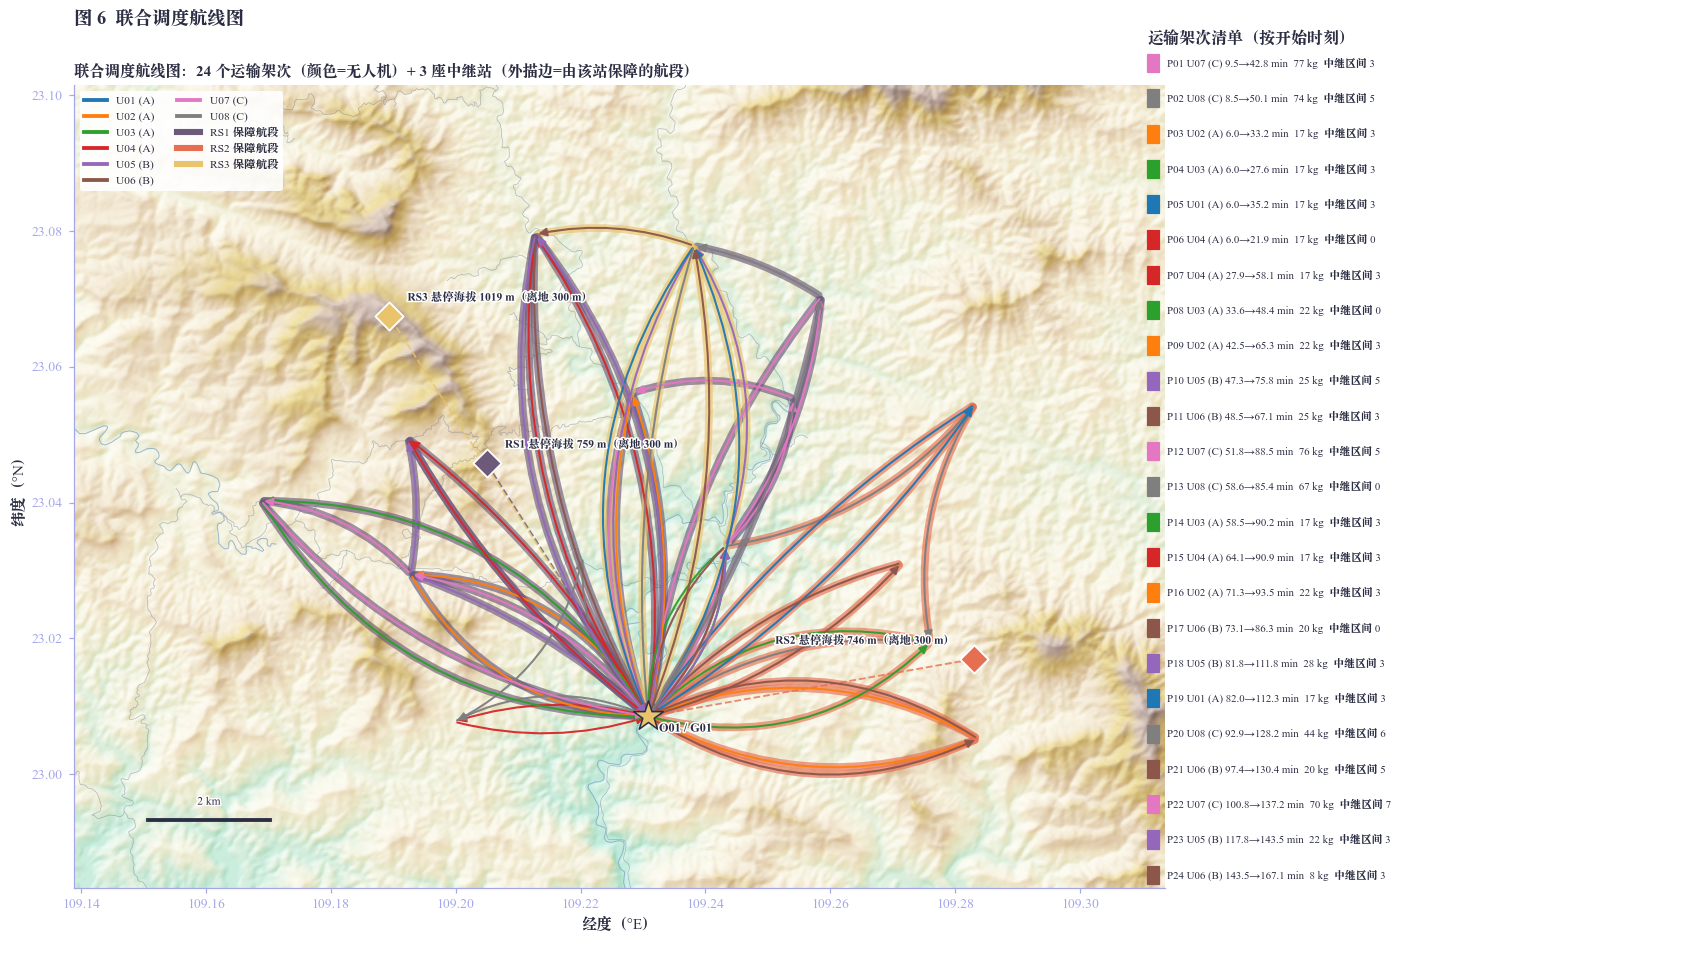

In [14]:
# 图 6：运输航线、中继站、回传链路与覆盖归属。
UAV_COLOR={u:plt.cm.tab10(i%10) for i,u in enumerate(UAV_LIST)}
fig=plt.figure(figsize=(16,9.2))
ax=fig.add_axes([0.04,0.06,0.62,0.9]);base_map(ax)
ax.add_collection(LineCollection([grp[['经度','纬度']].values for _,grp in roads.groupby('道路要素编号')],
                                 colors='#7B8194',linewidths=0.5,alpha=0.5,zorder=1))
for r in plan_df.itertuples(index=False):
    k=int(r.架次[1:]);col=UAV_COLOR[r.无人机];rad=0.10+0.045*(k%5)
    nodes=[0]+[AREA_IDX[x] for x in r.路线.split('→')[1:-1]]+[0]
    for i,j in zip(nodes[:-1],nodes[1:]):
        v=LEG[(i,j)];need=~v['direct']
        xy=(LONS[j],LATS[j]);xy0=(LONS[i],LATS[i])
        if need.any():
            sidx=int(np.argmax(v['cov'][need].sum(axis=0)));rc=ST_COLOR[sidx]
            ax.annotate('',xy=xy,xytext=xy0,zorder=3,
                        arrowprops=dict(arrowstyle='-',connectionstyle=f'arc3,rad={rad}',color=rc,lw=5.0,alpha=0.65))
        ax.annotate('',xy=xy,xytext=xy0,zorder=4,
                    arrowprops=dict(arrowstyle='-|>',mutation_scale=11,connectionstyle=f'arc3,rad={rad}',color=col,lw=1.35,alpha=0.95))
for s,(lon,lat),xyz in zip(range(len(ST_NAMES)),ST_LONLAT,ST_XYZ):
    ax.plot([LONS[0],lon],[LATS[0],lat],ls='--',color=ST_COLOR[s],lw=1.2,alpha=0.8,zorder=2)
    ax.scatter(lon,lat,s=170,marker='D',color=ST_COLOR[s],edgecolor='white',linewidth=1.2,zorder=8)
    right=lon>(extent[0]+extent[1])/2
    ax.annotate(f'{ST_NAMES[s]} 悬停海拔 {xyz[2]:.0f} m（离地 {AGL_RELAY:.0f} m）',(lon,lat),
                xytext=(-12 if right else 12,10),textcoords='offset points',fontsize=7.5,
                ha='right' if right else 'left',fontweight='bold',
                path_effects=[pe.withStroke(linewidth=2,foreground='white')],zorder=9)
ax.scatter(LONS[0],LATS[0],s=420,marker='*',color=PAL['gold'],edgecolor=PAL['ink'],linewidth=1.0,zorder=10)
ax.annotate('O01 / G01',(LONS[0],LATS[0]),xytext=(7,-10),textcoords='offset points',fontsize=8,
            fontweight='bold',path_effects=[pe.withStroke(linewidth=2,foreground='white')],zorder=11)
ax.set_xlabel('经度（°E）');ax.set_ylabel('纬度（°N）')
handles=[Line2D([],[],color=UAV_COLOR[u],lw=2.5,label=f'{u} ({UAV_TYPE[u]})') for u in UAV_LIST]
handles += [Line2D([],[],color=ST_COLOR[s],lw=4,label=f'{ST_NAMES[s]} 保障航段') for s in range(len(ST_NAMES))]
ax.legend(handles=handles,loc='upper left',ncol=2,fontsize=7.5,frameon=True,framealpha=0.9,edgecolor='none')
sb=2000/m_per_deg_lon;x0=extent[0]+0.012;y0=extent[2]+0.010
ax.plot([x0,x0+sb],[y0,y0],color=PAL['ink'],lw=2.5,zorder=12)
ax.text(x0+sb/2,y0+0.002,'2 km',ha='center',va='bottom',fontsize=7.5,
        path_effects=[pe.withStroke(linewidth=2,foreground='white')],zorder=12)
ax.set_title(f'联合调度航线图：{len(plan_df)} 个运输架次（颜色=无人机）+ {len(ST_NAMES)} 座中继站（外描边=由该站保障的航段）',loc='left',fontsize=10)
ax2=fig.add_axes([0.65,0.06,0.31,0.9]);ax2.axis('off')
ax2.text(0,1.0,'运输架次清单（按开始时刻）',fontsize=10.5,fontweight='bold',va='top')
for i,r in enumerate(plan_df.sort_values('开始_s').itertuples(index=False)):
    y=0.965-i*(0.93/max(24,len(plan_df)))
    ax2.add_patch(Rectangle((0,y-0.010),0.022,0.020,color=UAV_COLOR[r.无人机],transform=ax2.transAxes,clip_on=False))
    ax2.text(0.035,y,f'{r.架次} {r.无人机} ({r.机型}) {r.起飞_s/60:.1f}→{r.返仓_s/60:.1f} min  {r.质量_kg:.0f} kg  中继区间 {r.中继需求区间数}',
             fontsize=7.1,va='center',transform=ax2.transAxes)
fig.suptitle('图 6  联合调度航线图',x=0.04,ha='left',fontsize=12,fontweight='bold')
fig.tight_layout(rect=[0,0,1,0.97]);savefig(fig,'图06_联合调度航线图');plt.show()

## 17 图7:联合调度甘特图

上层：8 架运输机的架次条，条下方叠加一条通信状态色带（青绿 = 直连、紫 = RS1 中继、深红 = RS2 中继、黑 = 中断）；中层：2 架中继机的架次（准备/飞行 = 浅色，在站服务 = 深色，标注服务站与结束 SOC）；下层：6 组能源组件的占用与两阶段充电。三层共用时间轴，能直接核对“运输机进入阴影时中继是否已在站”。


🖼️ 已保存 问题三/图07_联合调度甘特图.png


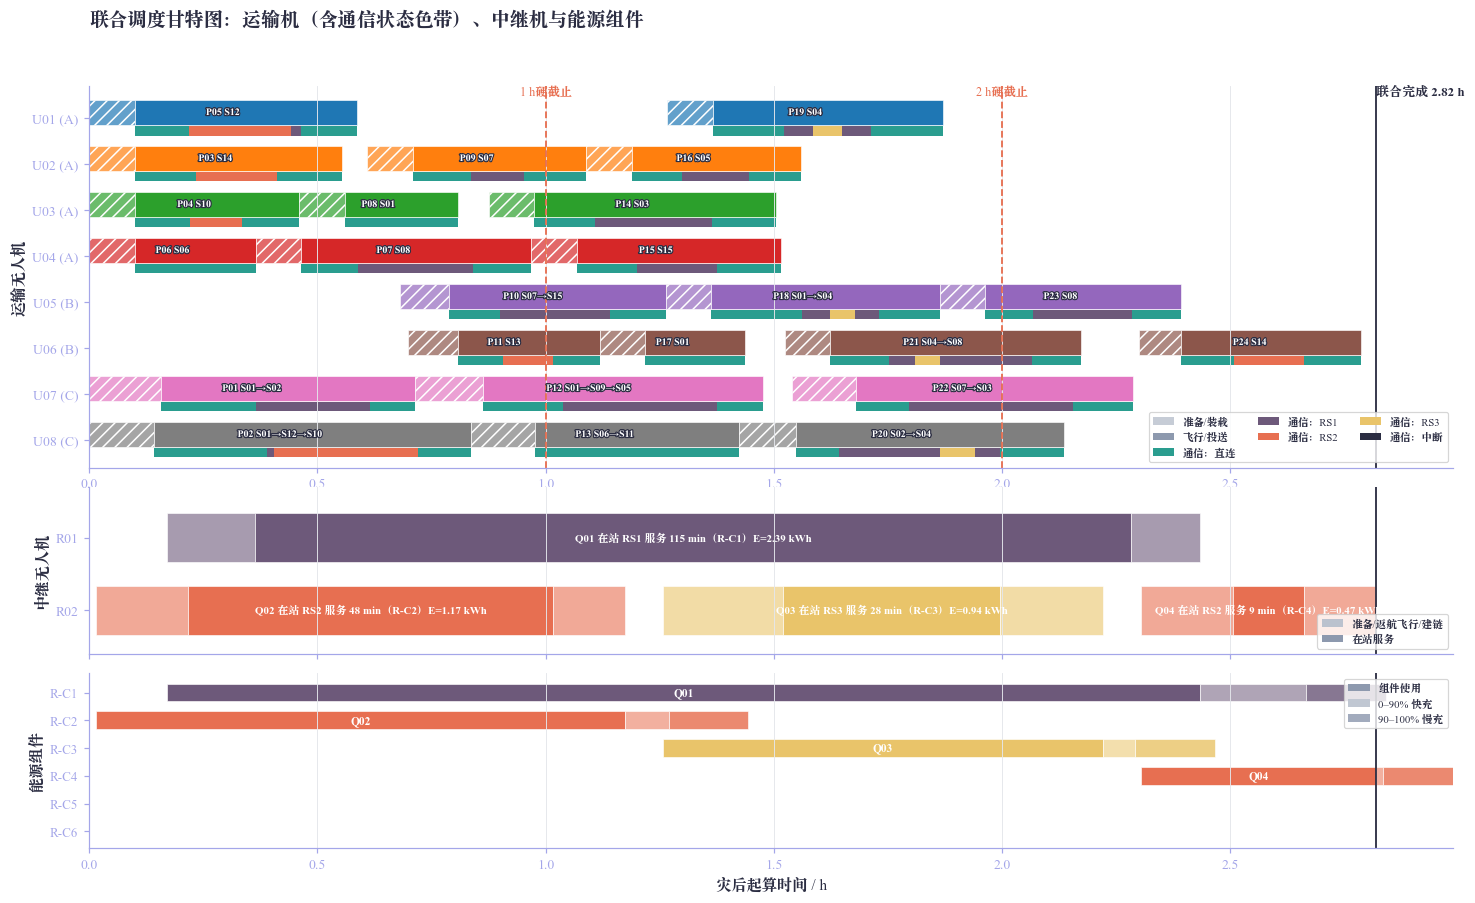

In [15]:
# 图 7：联合调度甘特图（运输机通信状态、中继机服务与能源组件充电共用时间轴）。
def shade(color, strength):
    rgb=np.asarray(mpl.colors.to_rgb(color))
    return mpl.colors.to_hex(1-strength+strength*rgb)

STATE_COLOR={'直连':PAL['teal'],**{name:ST_COLOR[i] for i,name in enumerate(ST_NAMES)},'中断':PAL['ink']}
mk_h=max(float(plan_df['返仓_s'].max()),float(relay_df['返仓_s'].max()))/3600
fig=plt.figure(figsize=(16,9))
gs=fig.add_gridspec(3,1,height_ratios=[2.4,1.05,1.1],hspace=0.08)
ax=fig.add_subplot(gs[0])
ax.grid(False,axis='y')
ypos={u:i for i,u in enumerate(UAV_LIST)}
phase_rows=[]
for r in plan_df.itertuples(index=False):
    phase_rows.extend([(r.无人机,'prep',r.开始_s,r.起飞_s),(r.无人机,'fly',r.起飞_s,r.返仓_s)])
phase_df=pd.DataFrame(phase_rows,columns=['无人机','阶段','开始_s','结束_s'])
for r in phase_df.itertuples(index=False):
    y=ypos[r.无人机];col=UAV_COLOR[r.无人机]
    fc=shade(col,0.7) if r.阶段=='prep' else (col if r.阶段=='fly' else shade(col,0.35))
    if r.结束_s>r.开始_s:
        ax.add_patch(Rectangle((r.开始_s/3600,y-0.40),(r.结束_s-r.开始_s)/3600,0.56,
                               facecolor=fc,edgecolor='white',lw=0.4,hatch='///' if r.阶段=='prep' else None))
k_by_pid={v:k for k,v in PID.items()}
for r in plan_df.itertuples(index=False):
    y=ypos[r.无人机];tl=sorted(COMM[k_by_pid[r.架次]],key=lambda x:x[0])
    route=r.路线.replace('O01→','').replace('→O01','').replace('S0','S')
    ax.text((r.开始_s+r.返仓_s)/7200,y-0.12,f'{r.架次} {route}',ha='center',va='center',fontsize=6.5,
            color='white',fontweight='bold',path_effects=[pe.withStroke(linewidth=1.5,foreground=PAL['ink'])])
    if tl:
        tl=[(min(float(t),float(r.返仓_s)),s) for t,s in tl if t<=r.返仓_s+1e-9]
        ts=[t for t,_ in tl]+[float(r.返仓_s)];ss=[s for _,s in tl];k0=0
        for k in range(1,len(ss)+1):
            if k==len(ss) or ss[k]!=ss[k0]:
                if ts[k]>ts[k0]:
                    ax.add_patch(Rectangle((ts[k0]/3600,y+0.18),(ts[k]-ts[k0])/3600,0.20,
                                           facecolor=STATE_COLOR.get(ss[k0],PAL['ink']),edgecolor='none'))
                k0=k
for h in [1,2,3]:
    if h<mk_h*1.06:
        ax.axvline(h,color=PAL['coral'],lw=1.2,ls='--',zorder=2)
        ax.text(h,-0.7,f'{h} h硬截止',color=PAL['coral'],fontsize=8,ha='center',va='top')
ax.axvline(mk_h,color=PAL['ink'],lw=1.2,zorder=2)
ax.text(mk_h,-0.7,f'联合完成 {mk_h:.2f} h',fontsize=8.5,va='top',fontweight='bold')
ax.set_yticks(range(len(UAV_LIST)));ax.set_yticklabels([f'{u} ({UAV_TYPE[u]})' for u in UAV_LIST])
ax.invert_yaxis();ax.set_ylim(len(UAV_LIST)-0.4,-0.7);ax.set_ylabel('运输无人机')
state_handles=[Rectangle((0,0),1,1,facecolor=STATE_COLOR[s],label=f'通信：{s}') for s in STATE_COLOR]
phase_handles=[Rectangle((0,0),1,1,facecolor=shade(PAL['grey'],0.5),label='准备/装载'),
               Rectangle((0,0),1,1,facecolor=PAL['grey'],label='飞行/投送')]
ax.legend(handles=phase_handles+state_handles,loc='lower right',ncol=3,fontsize=7,frameon=True)
ax.set_title('联合调度甘特图：运输机（含通信状态色带）、中继机与能源组件',loc='left',fontsize=12.5,pad=40)

# --- 中继机 ---
ax=fig.add_subplot(gs[1],sharex=ax);ax.grid(False,axis='y')
rpos={r:k for k,r in enumerate(RELAYS)}
for r in relay_df.itertuples(index=False):
    y=rpos[r.中继无人机];col=ST_COLOR[ST_NAMES.index(r.中继站)]
    ax.add_patch(Rectangle((r.出发_s/3600,y-0.34),(r.建链完成_s-r.出发_s)/3600,0.68,
                           facecolor=shade(col,0.6),edgecolor='white',lw=0.4))
    ax.add_patch(Rectangle((r.建链完成_s/3600,y-0.34),(r.服务结束_s-r.建链完成_s)/3600,0.68,
                           facecolor=col,edgecolor='white',lw=0.4))
    ax.add_patch(Rectangle((r.服务结束_s/3600,y-0.34),(r.返仓_s-r.服务结束_s)/3600,0.68,
                           facecolor=shade(col,0.6),edgecolor='white',lw=0.4))
    ax.text((r.建链完成_s+r.服务结束_s)/7200,y,
            f'{r.中继架次} 在站 {r.中继站} 服务 {r.服务_s/60:.0f} min（{r.组件}）E={r.能耗_kWh:.2f} kWh',
            ha='center',va='center',fontsize=7.2,color='white',fontweight='bold')
ax.axvline(mk_h,color=PAL['ink'],lw=1.2,zorder=2)
ax.set_yticks(range(len(RELAYS)));ax.set_yticklabels(RELAYS);ax.invert_yaxis()
ax.set_ylim(len(RELAYS)-0.4,-0.7);ax.tick_params(axis='x',labelbottom=False);ax.set_ylabel('中继无人机')
ax.legend(handles=[Rectangle((0,0),1,1,facecolor=shade(PAL['grey'],0.6),label='准备/返航飞行/建链'),
                   Rectangle((0,0),1,1,facecolor=PAL['grey'],label='在站服务')],
          loc='lower right',fontsize=7,frameon=True)

# --- 能源组件 ---
ax=fig.add_subplot(gs[2],sharex=ax);ax.grid(False,axis='y');cpos={c:k for k,c in enumerate(COMPS)}
for r in relay_df.itertuples(index=False):
    y=cpos[r.组件];col=ST_COLOR[ST_NAMES.index(r.中继站)]
    ax.add_patch(Rectangle((r.出发_s/3600,y-0.32),(r.返仓_s-r.出发_s)/3600,0.64,
                           facecolor=col,edgecolor='white',lw=0.4))
    t_fast=r.返仓_s+T_FULL_R*0.65*(0.9-r.返仓SOC)/0.9 if r.返仓SOC<0.9 else r.返仓_s
    t_fast=min(float(t_fast),float(r.组件再可用_s))
    if t_fast>r.返仓_s:
        ax.add_patch(Rectangle((r.返仓_s/3600,y-0.32),(t_fast-r.返仓_s)/3600,0.64,
                               facecolor=shade(col,0.55),edgecolor='white',lw=0.4))
    if r.组件再可用_s>t_fast:
        ax.add_patch(Rectangle((t_fast/3600,y-0.32),(r.组件再可用_s-t_fast)/3600,0.64,
                               facecolor=shade(col,0.82),edgecolor='white',lw=0.4))
    ax.text((r.出发_s+r.返仓_s)/7200,y,r.中继架次,ha='center',va='center',fontsize=7.5,
            color='white',fontweight='bold',zorder=3)
ax.axvline(mk_h,color=PAL['ink'],lw=1.2,zorder=2)
ax.set_yticks(range(len(COMPS)));ax.set_yticklabels(COMPS,fontsize=8.5);ax.invert_yaxis()
ax.set_ylim(len(COMPS)-0.4,-0.7);ax.set_xlabel('灾后起算时间 / h');ax.set_ylabel('能源组件')
ax.set_xlim(0,max(mk_h*1.06,0.5))
ax.legend(handles=[Rectangle((0,0),1,1,facecolor=PAL['grey'],label='组件使用'),
                   Rectangle((0,0),1,1,facecolor=shade(PAL['grey'],0.55),label='0–90% 快充'),
                   Rectangle((0,0),1,1,facecolor=shade(PAL['grey'],0.82),label='90–100% 慢充')],
          loc='upper right',fontsize=7,frameon=True)
fig.tight_layout(rect=[0,0,1,0.96]);savefig(fig,'图07_联合调度甘特图');plt.show()

## 18 图 8：通信保障统计与中继负载

（a） 每个运输架次的通信状态时长构成（直连/RS1/RS2/中断）；（b）任意时刻各中继站同时保障的运输机数量与中继在站窗口——中继在站窗口必须完全包住 有需求的时段；（C） 两个中继架次的能量预算构成（往返飞行/建链/在站服务／剩余）。


🖼️ 已保存 问题三/图08_通信保障统计.png


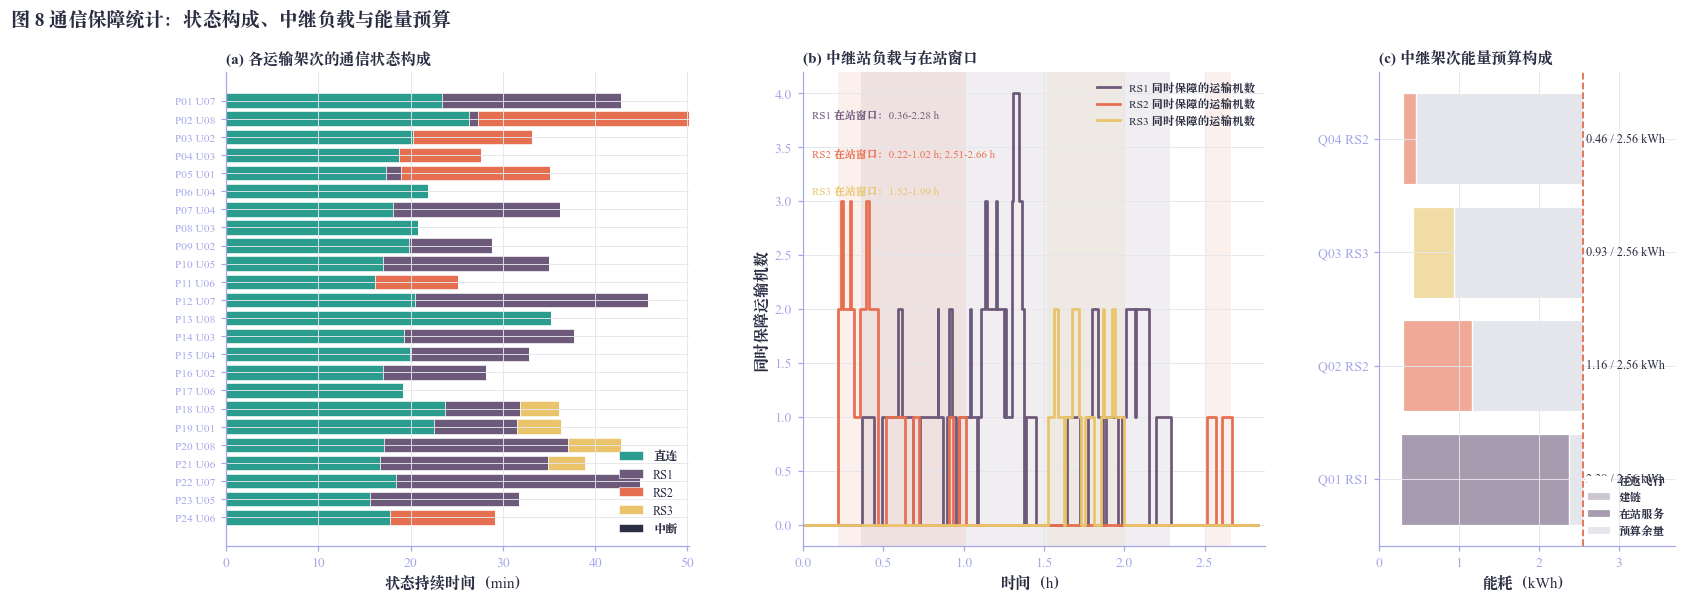

In [16]:
# 图 8：通信保障统计与中继负载。
fig=plt.figure(figsize=(17,5.6));gs=fig.add_gridspec(1,3,width_ratios=[1.25,1.25,0.8],wspace=0.28)
ax=fig.add_subplot(gs[0])
order_k=sorted(range(len(PLAN_SORTIES)),key=lambda k:PLAN_M['schedule'][k][2]);left=np.zeros(len(order_k))
for s in STATE_COLOR:
    vals=np.array([state_share(COMM[k])[s]*PLAN_SORTIES[k].ev['dur']/60 for k in order_k])
    ax.barh(range(len(order_k)),vals,left=left,color=STATE_COLOR[s],edgecolor='white',lw=0.4,label=s);left+=vals
ax.set_yticks(range(len(order_k)));ax.set_yticklabels([f'{PID[k]} {PLAN_M["schedule"][k][0]}' for k in order_k],fontsize=7.5);ax.invert_yaxis()
ax.set_xlabel('状态持续时间（min）');ax.legend(loc='lower right',fontsize=8);ax.set_title('(a) 各运输架次的通信状态构成',loc='left',fontsize=10)

ax=fig.add_subplot(gs[1])
tg=np.arange(0,PLAN_M['makespan']+60,20.0)
ON_raw=[[] for _ in ST_NAMES]
for v in PLAN_M['relay_sessions']:
    ON_raw[v['station']].append((float(v['linked']),float(v['service_end'])))
ON=[]
for intervals in ON_raw:
    merged=[]
    for a,b in sorted(intervals):
        if merged and a<=merged[-1][1]+1e-9:merged[-1]=(merged[-1][0],max(merged[-1][1],b))
        else:merged.append((a,b))
    ON.append(merged)
for s,col in zip(range(len(ST_NAMES)),ST_COLOR):
    load=np.zeros(len(tg),int)
    for k in range(len(PLAN_SORTIES)):
        st=PLAN_M['schedule'][k][2]
        for a,b,ss in PLAN_SORTIES[k].ev['relay']:
            if ss==s:load+=(tg>=st+a)&(tg<=st+b)
    ax.step(tg/3600,load,where='post',color=col,lw=1.8,label=f'{ST_NAMES[s]} 同时保障的运输机数')
    for a,b in ON[s]:ax.axvspan(a/3600,b/3600,color=col,alpha=0.10,lw=0)
    ax.text(0.02,0.92-0.08*s,f'{ST_NAMES[s]} 在站窗口：'+('; '.join(f'{a/3600:.2f}-{b/3600:.2f} h' for a,b in ON[s]) if ON[s] else '无'),
            transform=ax.transAxes,fontsize=7.2,color=col,va='top')
ax.set_xlabel('时间（h）');ax.set_ylabel('同时保障运输机数');ax.set_xlim(0,PLAN_M['makespan']/3600*1.02);ax.legend(loc='upper right',fontsize=7.5)
ax.set_title('(b) 中继站负载与在站窗口',loc='left',fontsize=10)

ax=fig.add_subplot(gs[2])
for k,r in enumerate(relay_df.itertuples(index=False)):
    s=ST_NAMES.index(r.中继站);f=RELAY_FLIGHT[s];col=ST_COLOR[s]
    parts=(('往返飞行',f[2]+f[3]),
           ('建链',(R['P_hover']+R['P_comm'])*R['t_link']/3600),
           ('在站服务',(R['P_hover']+R['P_comm'])*max(r.服务_s-R['t_link'],0)/3600))
    left=0
    for (lab,val),kk in zip(parts,(0.0,0.35,0.6)):
        ax.barh(k,val,left=left,color=shade(col,kk),edgecolor='white',label=lab if k==0 else None);left+=val
    ax.barh(k,R['budget']-left,left=left,color=PAL['mist'],edgecolor='white',label='预算余量' if k==0 else None)
    ax.text(R['budget']+0.03,k,f'{left:.2f} / {R["budget"]:.2f} kWh',va='center',fontsize=8)
ax.axvline(R['budget'],color=PAL['coral'],ls='--',lw=1.2);ax.set_yticks(range(len(relay_df)))
ax.set_yticklabels([f'{r.中继架次} {r.中继站}' for r in relay_df.itertuples(index=False)])
ax.set_xlim(0,R['budget']*1.45);ax.set_xlabel('能耗（kWh）');ax.legend(loc='lower right',fontsize=7.5)
ax.set_title('(c) 中继架次能量预算构成',loc='left',fontsize=10)
fig.suptitle('图 8 通信保障统计：状态构成、中继负载与能量预算',x=0.01,ha='left',fontsize=12.5,fontweight='bold')
fig.tight_layout();savefig(fig,'图08_通信保障统计');plt.show()

## 19 图 9：四指标权衡与“通信保障的代价”

(a) 五个方案的平行坐标；(b) 搜索到的可行解与四维非支配解（横轴联合完成时间、纵轴总能耗、颜色及时性、点面积总架次）。与问题二相比，中继机的往返与在站能耗使总能耗整体抬升，联合完成时间比运输完成时间多出中继返回的十余分钟——这就是通信保障的代价。


🖼️ 已保存 问题三/图09_指标权衡.png


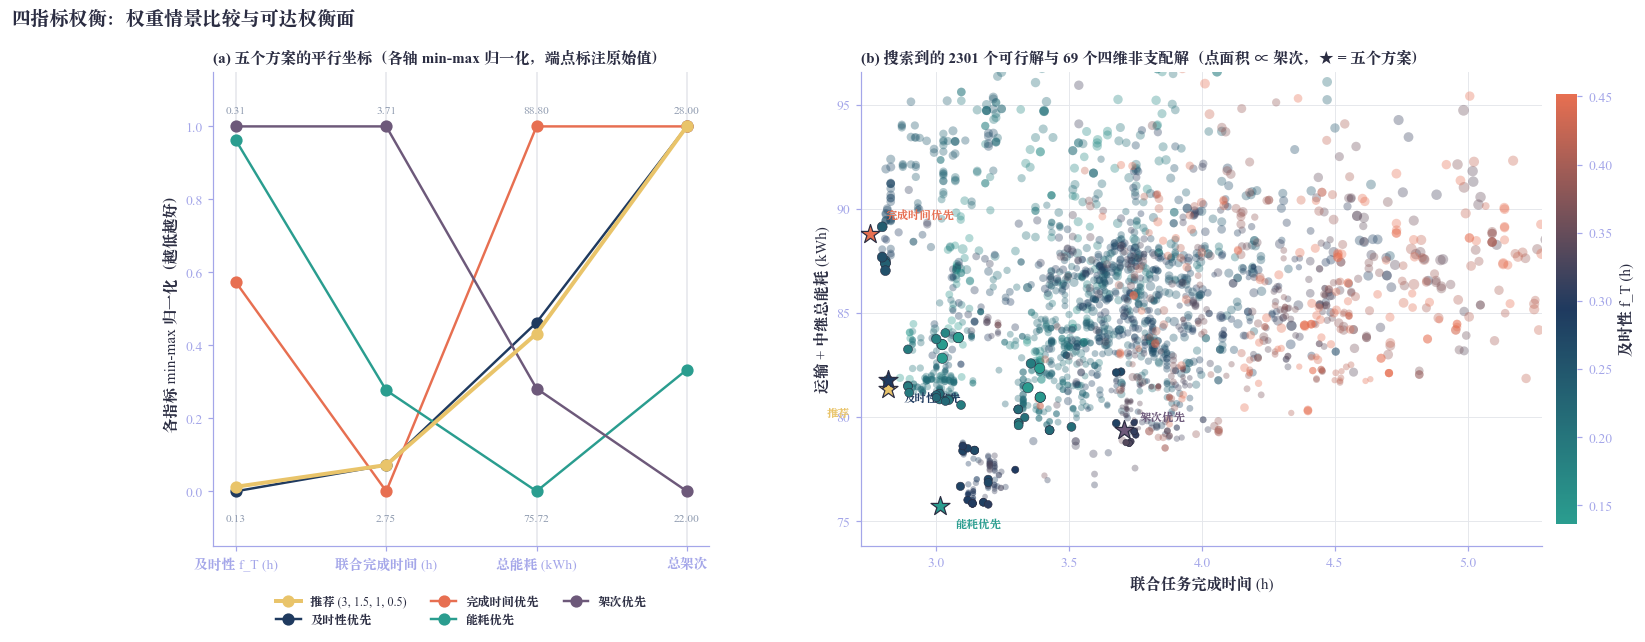

In [17]:
fig=plt.figure(figsize=(16,5.6));gs=fig.add_gridspec(1,2,width_ratios=[0.9,1.3],wspace=0.25)
ax=fig.add_subplot(gs[0]);ax.grid(False)
mets=['及时性T','联合完成时间_h','总能耗_kWh','总架次'];scen_df['总架次']=scen_df['运输架次']+scen_df['中继架次'];M=scen_df[mets].to_numpy(float)
lo=M.min(axis=0);hi=M.max(axis=0)
Mn=(M-lo)/np.where(hi-lo>0,hi-lo,1)
scols=[PAL['gold'],PAL['indigo'],PAL['coral'],PAL['teal'],PAL['plum']]
for k,(name,row) in enumerate(zip(scen_df.index,Mn)):
    ax.plot(range(4),row,marker='o',ms=7,lw=2.6 if k==0 else 1.6,color=scols[k],label=name,zorder=5 if k==0 else 3)
for j in range(4):
    ax.axvline(j,color=PAL['mist'],lw=1,zorder=1)
    ax.text(j,-0.06,f'{lo[j]:.2f}',ha='center',va='top',fontsize=7.5,color=PAL['grey'])
    ax.text(j,1.03,f'{hi[j]:.2f}',ha='center',va='bottom',fontsize=7.5,color=PAL['grey'])
ax.set_xticks(range(4));ax.set_xticklabels(['及时性 f_T (h)','联合完成时间 (h)','总能耗 (kWh)','总架次'])
ax.set_ylim(-0.15,1.15);ax.set_ylabel('各指标 min-max 归一化（越低越好）')
ax.legend(loc='upper center',bbox_to_anchor=(0.5,-0.08),ncol=3,fontsize=8)
ax.set_title('(a) 五个方案的平行坐标（各轴 min-max 归一化，端点标注原始值）',loc='left',fontsize=10)

ax=fig.add_subplot(gs[1])
fT_all=pts[:,0];norm_T=Normalize(fT_all.min(),np.percentile(fT_all,95))
ax.scatter(pts[~nd,1],pts[~nd,2],c=fT_all[~nd],cmap=CMAP_SEQ,norm=norm_T,
           s=8+3*(pts[~nd,3]-pts[:,3].min()),alpha=0.35,lw=0,zorder=2)
sc=ax.scatter(pts[nd,1],pts[nd,2],c=fT_all[nd],cmap=CMAP_SEQ,norm=norm_T,
              s=18+4*(pts[nd,3]-pts[:,3].min()),edgecolor=PAL['ink'],lw=0.35,zorder=4)
offs=((-40,-18),(10,-14),(10,10),(10,-14),(10,6))
for k,(name,row) in enumerate(scen_df.iterrows()):
    ax.scatter(float(row['联合完成时间_h']),float(row['总能耗_kWh']),s=170,marker='*',color=scols[k],
               edgecolor=PAL['ink'],lw=0.8,zorder=6)
    ax.annotate(name.split(' (')[0],(float(row['联合完成时间_h']),float(row['总能耗_kWh'])),
                xytext=offs[k],textcoords='offset points',fontsize=7.5,color=scols[k],fontweight='bold')
ax.set_xlim(pts[:,1].min()-0.08,np.percentile(pts[:,1],99));ax.set_ylim(pts[:,2].min()-2,np.percentile(pts[:,2],99))
cb=fig.colorbar(sc,ax=ax,fraction=0.03,pad=0.02);cb.set_label('及时性 f_T (h)');cb.outline.set_visible(False)
ax.set_xlabel('联合任务完成时间 (h)');ax.set_ylabel('运输 + 中继总能耗 (kWh)')
ax.set_title(f'(b) 搜索到的 {len(pts)} 个可行解与 {int(nd.sum())} 个四维非支配解（点面积 ∝ 架次，★ = 五个方案）',loc='left',fontsize=10)
fig.suptitle('四指标权衡：权重情景比较与可达权衡面',x=0.01,ha='left',fontsize=12.5,fontweight='bold')
savefig(fig,'图09_指标权衡');plt.show()

## 20 可行性与通信连续性检验、图 10

在问题二 8 项检验之外增加 4 项：⑨ 中继悬停位置在 DEM 范围内且离地高度 ≤ 300 m；⑩ 中继架次能耗 ≤ 预算，能源组件占用—充满—再占用不重叠，同机相邻架次间隔 ≥ 周转时间；⑪ 回传链路可用；⑫ 全部运输架次以 5 s 步长独立复核无通信中断。图 10 给出电池/组件 SOC 轨迹与逐箱送达对比。


,检查项,通过,说明
0,① 每箱恰好装运一次,True,80 箱，80 个不同编号
1,② 载质量/体积/能量约束,True,最紧约束利用率 99.9%
2,③ 无人机架次不重叠,True,相邻架次最小间隔 0 s
3,④ 电池占用—充满—再占用不重叠,True,充电结束到再次使用最小间隔 0 s
4,⑤ 任务结束 SOC ≥ 返航电量下限,True,最低返仓 SOC 20.1%
5,⑥ 医疗物资与首批硬时限,True,31 箱，最小提前量 0.8 min
6,⑦ 电池使用数 ≤ 库存,True,"A: 6/6, B: 4/4, C: 4/4"
7,⑧ 从 O01 出发并返回，开始时刻 ≥ 0,True,24 个运输架次
8,⑨ 中继悬停点在 DEM 范围内且离地高度 ≤ 上限,True,3 个站，离地 300 m ≤ 300 m
9,⑩ 中继能耗 ≤ 预算、SOC ≥ 下限，组件与中继周转不重叠,True,最大能耗 2.39/2.56 kWh，最低 SOC 25%


可行性与通信连续性检查：全部 12 项通过 ✓
🖼️ 已保存 问题三/图10_SOC轨迹与逐箱送达.png


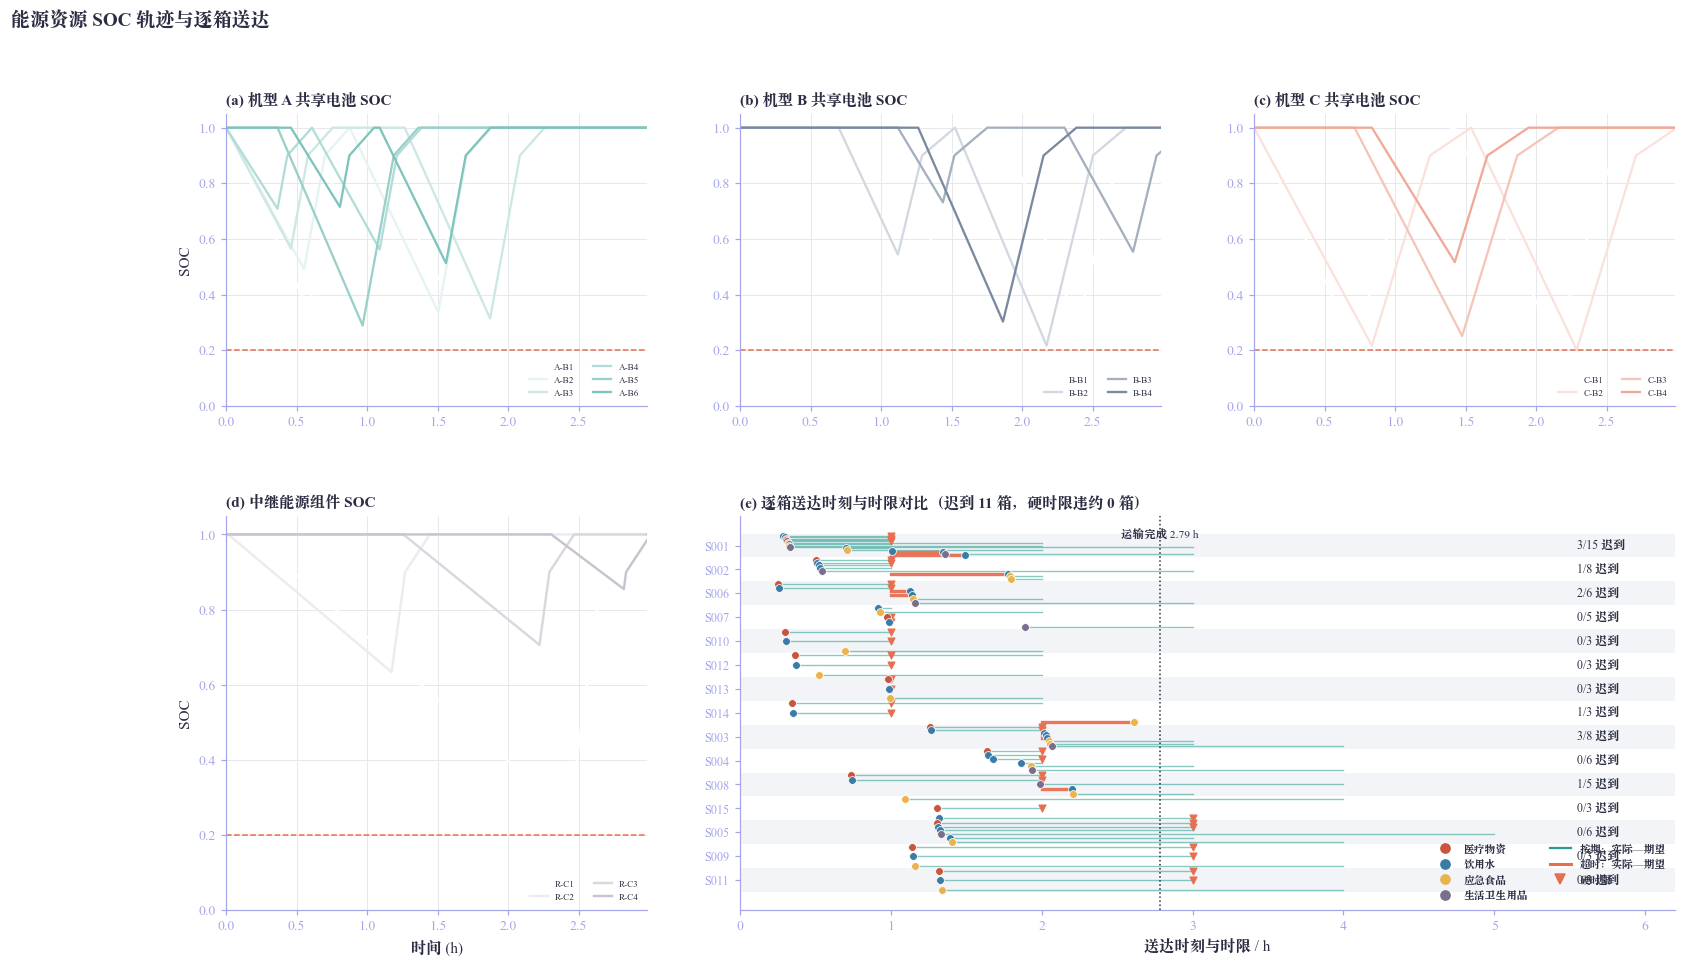

In [18]:
def verify(plan_df,box_df,bat_df,sorties,m):
    res=[]
    ok=len(box_df)==NB and box_df['货箱'].is_unique and set(box_df['货箱'])==set(b_id)
    res.append(('① 每箱恰好装运一次',ok,f'{len(box_df)} 箱，{box_df["货箱"].nunique()} 个不同编号'))
    ok=True;worst=0.0
    for s in sorties:
        ev=eval_sortie(s.g,s.stops);ok &= ev is not None
        if ev is not None:worst=max(worst,ev['E']/BUDGET[s.g],ev['mass']/P[s.g]['Q'],ev['vol']/P[s.g]['V'])
    res.append(('② 载质量/体积/能量约束',ok,f'最紧约束利用率 {worst*100:.1f}%'))
    ok=True;gap=math.inf
    for u in UAV_LIST:
        d=plan_df[plan_df['无人机']==u].sort_values('开始_s')
        for a,b in zip(d['返仓_s'].iloc[:-1],d['开始_s'].iloc[1:]):ok &= b>=a-1e-6;gap=min(gap,b-a)
    res.append(('③ 无人机架次不重叠',ok,f'相邻架次最小间隔 {gap:.0f} s' if gap<math.inf else '无相邻架次'))
    ok=True;gap=math.inf
    for bt,_ in BATS:
        d=bat_df[bat_df['电池']==bt].sort_values('开始_s')
        for a,b in zip(d['电池再可用_s'].iloc[:-1],d['开始_s'].iloc[1:]):ok &= b>=a-1e-6;gap=min(gap,b-a)
    res.append(('④ 电池占用—充满—再占用不重叠',ok,f'充电结束到再次使用最小间隔 {gap:.0f} s' if gap<math.inf else '无重复使用'))
    ok=(plan_df['返仓SOC']>=plan_df['机型'].map(lambda g:P[g]['rho'])-1e-9).all()
    res.append(('⑤ 任务结束 SOC ≥ 返航电量下限',ok,f'最低返仓 SOC {plan_df["返仓SOC"].min():.1%}'))
    hard=box_df[box_df['硬时限_s'].notna()]
    ok=(hard['送达_s']<=hard['硬时限_s']+1e-6).all()
    margin=(hard['硬时限_s']-hard['送达_s']).min() if len(hard) else math.nan
    res.append(('⑥ 医疗物资与首批硬时限',ok,f'{len(hard)} 箱，最小提前量 {margin/60:.1f} min'))
    used=set(plan_df['电池']);cnt=Counter(g for b,g in BATS if b in used)
    ok=all(cnt[g]<=BATT[g][0] for g in TYPES)
    res.append(('⑦ 电池使用数 ≤ 库存',ok,', '.join(f'{g}: {cnt[g]}/{BATT[g][0]}' for g in TYPES)))
    ok=(plan_df['开始_s']>=-1e-9).all() and plan_df['路线'].str.startswith('O01').all() and plan_df['路线'].str.endswith('O01').all()
    res.append(('⑧ 从 O01 出发并返回，开始时刻 ≥ 0',ok,f'{len(plan_df)} 个运输架次'))
    return pd.DataFrame(res,columns=['检查项','通过','说明'])

VER=verify(plan_df,box_df,bat_df,PLAN_SORTIES,PLAN_M)
extra=[]
lon_ok=all(LON_C.min()<=ll[0]<=LON_C.max() and LAT_C.min()<=ll[1]<=LAT_C.max() for ll in ST_LONLAT)
agl_ok=(station_df['悬停离地_m']<=R['h_max']+1e-9).all()
extra.append(('⑨ 中继悬停点在 DEM 范围内且离地高度 ≤ 上限',bool(lon_ok and agl_ok),f'{len(ST_LONLAT)} 个站，离地 {AGL_RELAY:.0f} m ≤ {R["h_max"]:.0f} m'))
e_ok=(relay_df['能耗_kWh']<=R['budget']+1e-9).all();soc_ok=(relay_df['返仓SOC']>=R['rho']-1e-9).all()
gap_c=math.inf;ok_c=True
for c in COMPS:
    d=relay_df[relay_df['组件']==c].sort_values('出发_s')
    for a,b in zip(d['组件再可用_s'].iloc[:-1],d['出发_s'].iloc[1:]):ok_c &= b>=a-1e-6;gap_c=min(gap_c,b-a)
ok_r=True
for rr in RELAYS:
    d=relay_df[relay_df['中继无人机']==rr].sort_values('出发_s')
    for a,b in zip(d['返仓_s'].iloc[:-1],d['出发_s'].iloc[1:]):ok_r &= b>=a+R['t_turn']-1e-6
extra.append(('⑩ 中继能耗 ≤ 预算、SOC ≥ 下限，组件与中继周转不重叠',bool(e_ok and soc_ok and ok_c and ok_r),f'最大能耗 {relay_df["能耗_kWh"].max():.2f}/{R["budget"]:.2f} kWh，最低 SOC {relay_df["返仓SOC"].min():.0%}'))
extra.append(('⑪ 中继回传链路 R-G 可用',bool((station_df['回传链路损耗_dB']<=station_df['回传预算_dB']+1e-9).all()),', '.join(f'{r.中继站} {r.回传链路损耗_dB:.1f}≤{r.回传预算_dB:.0f} dB' for r in station_df.itertuples(index=False))))
interrupts=int((comm_samples['状态']=='中断').sum())
extra.append(('⑫ 运输机全程无通信中断（5 s 独立复核）',interrupts==0,f'{len(comm_samples)} 个采样点，中断 {interrupts} 个'))
VER=pd.concat([VER,pd.DataFrame(extra,columns=VER.columns)],ignore_index=True);display(VER)
print('可行性与通信连续性检查：'+('全部 12 项通过 ✓' if VER['通过'].all() else '存在未通过项 ×'))

# -------- 图 10 --------
fig=plt.figure(figsize=(17,9.4));gs=fig.add_gridspec(2,3,height_ratios=[1,1.35],hspace=0.32,wspace=0.22)
def soc_traj(uses,T_full,E_use,t_end):
    xs,ys=[0.],[1.]
    for a,b,soc,t_full_ch in uses:
        xs += [a,b];ys += [1.,soc]
        if soc<0.9:xs += [b+T_full*0.65*(0.9-soc)/0.9];ys += [0.9]
        xs += [b+t_full_ch];ys += [1.]
    xs.append(t_end);ys.append(1.)
    return np.array(xs)/3600,np.array(ys)

for k,g in enumerate(TYPES):
    ax=fig.add_subplot(gs[0,k]);bl=[b for b,gg in BATS if gg==g]
    for kk,bt in enumerate(bl):
        d=bat_df[bat_df['电池']==bt].sort_values('开始_s')
        if d.empty:continue
        uses=[(r.开始_s,r.返仓_s,r.返仓SOC,r.充电_s) for r in d.itertuples(index=False)]
        xs,ys=soc_traj(uses,BATT[g][1],P[g]['E_use'],PLAN_M['makespan']+600)
        ax.plot(xs,ys,color=shade(TYPE_COLOR[g],0.6*kk/max(1,len(bl)-1)),lw=1.5,label=bt)
    ax.axhline(P[g]['rho'],color=PAL['coral'],lw=1,ls='--');ax.set_ylim(0,1.05)
    ax.set_xlim(0,(PLAN_M['makespan']+600)/3600);ax.legend(loc='lower right',fontsize=6,ncol=2)
    ax.set_title(f'({chr(97+k)}) 机型 {g} 共享电池 SOC',loc='left',fontsize=10)
    if k==0:ax.set_ylabel('SOC')

ax=fig.add_subplot(gs[1,0])
for kk,c in enumerate(COMPS):
    d=relay_df[relay_df['组件']==c].sort_values('出发_s')
    if d.empty:continue
    uses=[(r.出发_s,r.返仓_s,r.返仓SOC,r.组件再可用_s-r.返仓_s) for r in d.itertuples(index=False)]
    xs,ys=soc_traj(uses,T_FULL_R,R['E_use'],PLAN_M['makespan']+600)
    ax.plot(xs,ys,color=shade(PAL['plum'],0.6*kk/max(1,N_COMP-1)),lw=1.6,label=c)
ax.axhline(R['rho'],color=PAL['coral'],lw=1,ls='--');ax.set_ylim(0,1.05)
ax.set_xlim(0,(PLAN_M['makespan']+600)/3600);ax.legend(loc='lower right',fontsize=6,ncol=2)
ax.set_xlabel('时间 (h)');ax.set_ylabel('SOC');ax.set_title('(d) 中继能源组件 SOC',loc='left',fontsize=10)

ax=fig.add_subplot(gs[1,1:])
areas_sorted=boxes.groupby('area').agg(h=('t_hard','min'),e=('expected','min')).sort_values(['h','e']).index.tolist()
for yi,a in enumerate(areas_sorted):
    sub_b=box_df[box_df['服务区']==a].sort_values('送达_s').reset_index(drop=True);n=len(sub_b)
    if yi%2==0:ax.axhspan(yi-0.5,yi+0.5,color='#F3F4F7',lw=0,zorder=0)
    for j,r in sub_b.iterrows():
        y=yi+(j-(n-1)/2)*(0.8/max(n-1,1)) if n>1 else yi
        t,te=r.送达_s/3600,r.期望_s/3600;ontime=te>=t
        ax.plot([t,te],[y,y],color=PAL['teal'] if ontime else PAL['coral'],lw=0.9 if ontime else 2.2,
                alpha=0.55 if ontime else 0.95,zorder=2)
        ax.scatter(t,y,s=26,color=MAT_COLOR[r.物资],edgecolor='white',lw=0.5,zorder=4)
        if not np.isnan(r.硬时限_s):ax.scatter(r.硬时限_s/3600,y,marker='v',s=20,color=PAL['coral'],zorder=3)
    ax.text(5.55,yi,f'{int(sub_b["是否迟到"].sum())}/{n} 迟到',va='center',fontsize=7.8)
ax.set_yticks(range(len(areas_sorted)));ax.set_yticklabels(areas_sorted,fontsize=8);ax.invert_yaxis();ax.grid(False)
ax.set_xlim(0,6.2);ax.axvline(PLAN_M['makespan_T']/3600,color=PAL['ink'],lw=1,ls=':')
ax.text(PLAN_M['makespan_T']/3600,-0.7,f'运输完成 {PLAN_M["makespan_T"]/3600:.2f} h',color=PAL['ink'],fontsize=7.5,ha='center',va='top')
handles=[Line2D([],[],marker='o',ls='none',color=MAT_COLOR[m],markersize=6,label=m) for m in MAT_ORDER]
handles += [Line2D([],[],color=PAL['teal'],lw=1.5,label='按期：实际—期望'),Line2D([],[],color=PAL['coral'],lw=2,label='超时：实际—期望'),
            Line2D([],[],marker='v',ls='none',color=PAL['coral'],markersize=6,label='硬时限')]
ax.legend(handles=handles,loc='lower right',fontsize=7,ncol=2)
ax.set_xlabel('送达时刻与时限 / h')
ax.set_title(f'(e) 逐箱送达时刻与时限对比（迟到 {int(box_df["是否迟到"].sum())} 箱，硬时限违约 {PLAN_M["hard_n"]} 箱）',loc='left',fontsize=10)
fig.suptitle('能源资源 SOC 轨迹与逐箱送达',x=0.01,ha='left',fontsize=12.5,fontweight='bold')
savefig(fig,'图10_SOC轨迹与逐箱送达');plt.show()

## 21 结果导出：问题四读取的方案工作簿

运行本节后，生成 `26-Modeling/001-Issue/D题/问题三结果.xlsx`，供问题四读取。工作簿包含运输架次、架次时间分段、中继需求区间、中继架次、中继站参数和逐箱送达时刻。

In [19]:
# 汇总联合调度器中的绝对时间需求窗，映射为结果表中的架次编号。
demand_rows = []
for sess in PLAN_M['relay_sessions']:
    st_name = ST_NAMES[sess['station']]
    for a, b, owner in sess.get('demands', []):
        demand_rows.append(dict(架次=PID[owner], 中继站=st_name, 开始_s=float(a), 结束_s=float(b)))
dem_iv = pd.DataFrame(demand_rows, columns=['架次', '中继站', '开始_s', '结束_s'])
dem_iv = dem_iv.sort_values(['架次', '开始_s', '中继站']).reset_index(drop=True)

# 问题四按这些站点往返与服务字段计算中继资源占用。
station_export_df = station_df.copy()
station_export_df['去程时间_s'] = [float(f[0]) for f in RELAY_FLIGHT]
station_export_df['回程时间_s'] = [float(f[1]) for f in RELAY_FLIGHT]
station_export_df['去程能耗_kWh'] = [float(f[2]) for f in RELAY_FLIGHT]
station_export_df['回程能耗_kWh'] = [float(f[3]) for f in RELAY_FLIGHT]
station_export_df['单组件最长在站_s'] = [float(v) for v in RELAY_ENDUR]

RESULT_DIR = BASE_DIR
xlsx_path = RESULT_DIR / '问题三结果.xlsx'
with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    plan_df.to_excel(writer, sheet_name='3_运输架次方案', index=False)
    seg_df.to_excel(writer, sheet_name='3_架次时间分段', index=False)
    dem_iv.to_excel(writer, sheet_name='3_中继需求区间', index=False)
    relay_df.to_excel(writer, sheet_name='3_中继架次方案', index=False)
    station_export_df.to_excel(writer, sheet_name='2_中继站', index=False)
    box_df.to_excel(writer, sheet_name='4_逐箱送达时刻', index=False)
print(f'问题三结果已导出：{xlsx_path}')

问题三结果已导出：/Users/fish/Documents/Math-Modeling/26-Modeling/001-Issue/D题/问题三结果.xlsx
